# Corrected whole-session locomotor spectral analysis

This notebook implements the corrected first-stage analysis for the AIR Wheel spectral project.

## Main corrections

1. True path speed is derived from native `dist_path_cm`.
2. Nonoverlapping frequency-bin sums make relative band powers sum to approximately 1.
3. Fast and slow PSDs are calculated separately:
   - fast: 10-s Welch windows, 0.1–20 Hz;
   - slow: 60-s Welch windows, 0.02–5 Hz.
4. Immobility uses total encoder-count change rather than count range.
5. Artifact QC flags corrupted sessions but retains them in the full table.
6. Summaries and PSD curves weight animals equally.
7. Experience effects use one slope per animal-phase plus leave-one-animal-out checks.
8. All plots are saved as PNG files.

Save the Python module as:

```text
src/proc/whole_session_spectral_batch.py
```

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

In [2]:
def find_repo_root(start_path=None):
    start_path = Path.cwd() if start_path is None else Path(start_path)
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src").is_dir():
            return candidate

    raise RuntimeError("Could not find the repository root containing src/.")


repo_root = find_repo_root()

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

Repository root: /home/nmldata2/ccaw/Python


In [3]:
import src.utils.config as config
import src.utils.data_io as dio

from src.proc.whole_session_spectral_batch2 import (
    WholeSessionSpectralConfig,
    build_whole_session_spectral_tables,
    save_whole_session_spectral_tables,
)

print("RAW_BASE:", config.RAW_BASE)
print("PROC_BASE:", config.PROC_BASE)

/home/nmldata2/ccaw/Python
RAW_BASE: /mnt/data/Classical_Conditioning
PROC_BASE: /mnt/pdata/Classical_Conditioning


## 1. Build `cc_data`

In [4]:
data_root = config.RAW_BASE
cc_data = dio.build_classical_conditioning_dict(data_root)
print("Top-level cc_data entries:", len(cc_data))

Top-level cc_data entries: 5


## 2. Configure corrected processing and QC

In [5]:
spectral_cfg = WholeSessionSpectralConfig(
    analysis_hz=100.0,
    derivative_window_ms=20.0,
    derivative_polyorder=3,
    speed_lowpass_hz=20.0,
    filter_order=4,

    fast_welch_window_s=10.0,
    fast_welch_overlap_fraction=0.50,
    fast_fmin_hz=0.10,
    fast_fmax_hz=20.0,

    slow_welch_window_s=60.0,
    slow_welch_overlap_fraction=0.50,
    slow_fmin_hz=0.02,
    slow_fmax_hz=5.0,

    behavior_window_s=2.0,
    movement_threshold_cms=0.20,

    fast_spectral_slope_fmin_hz=1.0,
    fast_spectral_slope_fmax_hz=10.0,

    qc_min_native_stored_r=0.90,
    qc_max_native_stored_rmse_cms=1.0,
    qc_max_abs_speed_cms=100.0,
    qc_max_native_position_step_cm=2.0,
    qc_large_encoder_jump_counts=5.0,
)

spectral_cfg

WholeSessionSpectralConfig(analysis_hz=100.0, derivative_window_ms=20.0, derivative_polyorder=3, speed_lowpass_hz=20.0, filter_order=4, fast_welch_window_s=10.0, fast_welch_overlap_fraction=0.5, fast_fmin_hz=0.1, fast_fmax_hz=20.0, slow_welch_window_s=60.0, slow_welch_overlap_fraction=0.5, slow_fmin_hz=0.02, slow_fmax_hz=5.0, behavior_window_s=2.0, movement_threshold_cms=0.2, fast_spectral_slope_fmin_hz=1.0, fast_spectral_slope_fmax_hz=10.0, qc_min_native_stored_r=0.9, qc_max_native_stored_rmse_cms=1.0, qc_max_abs_speed_cms=100.0, qc_max_native_position_step_cm=2.0, qc_large_encoder_jump_counts=5.0)

## 3. Select valid phases

Restricting the batch to the three experimental phases prevents `unknown` entries in `cc_data` from producing irrelevant file-not-found errors.

In [6]:
animals_to_process = None

phases_to_process = [
    "repeated_exposure",
    "air_training",
    "tone_air_training",
]

## 4. Run the corrected batch analysis

In [7]:
(
    whole_session_df,
    whole_session_psd_df,
    whole_session_errors_df,
) = build_whole_session_spectral_tables(
    cc_data=cc_data,
    config=spectral_cfg,
    root=None,
    animals=animals_to_process,
    phases=phases_to_process,
    verbose=True,
)

print()
print("Sessions processed:", len(whole_session_df))
print("Animals:", whole_session_df["animal"].nunique())
print("PSD rows:", len(whole_session_psd_df))
print("File-processing errors:", len(whole_session_errors_df))
print("QC failures:", int((~whole_session_df["qc_pass"]).sum()))

[1/217] NML_04 | 2025_12_27 | repeated_exposure
[2/217] NML_04 | 2025_12_28 | repeated_exposure
[3/217] NML_04 | 2025_12_29 | repeated_exposure
[4/217] NML_04 | 2025_12_30 | repeated_exposure
[5/217] NML_04 | 2025_12_31 | repeated_exposure
[6/217] NML_04 | 2026_01_01 | repeated_exposure
[7/217] NML_04 | 2026_01_02 | repeated_exposure
[8/217] NML_04 | 2026_01_03 | repeated_exposure
[9/217] NML_04 | 2026_01_04 | repeated_exposure
[10/217] NML_04 | 2026_01_05 | repeated_exposure
[11/217] NML_04 | 2026_01_06 | repeated_exposure
[12/217] NML_04 | 2026_01_07 | repeated_exposure
[13/217] NML_04 | 2026_01_08 | repeated_exposure
[14/217] NML_04 | 2026_01_09 | repeated_exposure
[15/217] NML_04 | 2026_01_10 | repeated_exposure
[16/217] NML_04 | 2026_01_11 | repeated_exposure
[17/217] NML_04 | 2026_01_12 | air_training
[18/217] NML_04 | 2026_01_13 | air_training
[19/217] NML_04 | 2026_01_14 | air_training
[20/217] NML_04 | 2026_01_15 | air_training
[21/217] NML_04 | 2026_01_16 | air_training
[22/2

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[155/217] NML_07 | 2026_03_06 | air_training
[156/217] NML_07 | 2026_03_07 | air_training
[157/217] NML_07 | 2026_03_08 | air_training
[158/217] NML_07 | 2026_03_09 | air_training
[159/217] NML_07 | 2026_03_10 | air_training
[160/217] NML_07 | 2026_03_11 | air_training
[161/217] NML_07 | 2026_03_12 | tone_air_training
[162/217] NML_07 | 2026_03_13 | tone_air_training
[163/217] NML_07 | 2026_03_14 | tone_air_training
[164/217] NML_07 | 2026_03_15 | tone_air_training
[165/217] NML_07 | 2026_03_16 | tone_air_training
[166/217] NML_07 | 2026_03_17 | tone_air_training
[167/217] NML_07 | 2026_03_18 | tone_air_training
[168/217] NML_07 | 2026_03_19 | tone_air_training
[169/217] NML_07 | 2026_03_20 | tone_air_training
[170/217] NML_07 | 2026_03_21 | tone_air_training
[171/217] NML_08 | 2026_02_02 | repeated_exposure
[172/217] NML_08 | 2026_02_03 | repeated_exposure
[173/217] NML_08 | 2026_02_04 | repeated_exposure
[174/217] NML_08 | 2026_02_05 | repeated_exposure
[175/217] NML_08 | 2026_02_06 

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[176/217] NML_08 | 2026_02_07 | repeated_exposure
[177/217] NML_08 | 2026_02_08 | repeated_exposure
[178/217] NML_08 | 2026_02_09 | repeated_exposure
[179/217] NML_08 | 2026_02_10 | repeated_exposure
[180/217] NML_08 | 2026_02_11 | repeated_exposure
[181/217] NML_08 | 2026_02_12 | repeated_exposure
[182/217] NML_08 | 2026_02_13 | repeated_exposure
[183/217] NML_08 | 2026_02_14 | repeated_exposure
[184/217] NML_08 | 2026_02_15 | repeated_exposure
[185/217] NML_08 | 2026_02_16 | repeated_exposure
[186/217] NML_08 | 2026_02_17 | repeated_exposure
[187/217] NML_08 | 2026_02_18 | repeated_exposure
[188/217] NML_08 | 2026_02_19 | repeated_exposure
[189/217] NML_08 | 2026_02_20 | repeated_exposure
[190/217] NML_08 | 2026_02_21 | air_training
[191/217] NML_08 | 2026_02_22 | air_training
[192/217] NML_08 | 2026_02_23 | air_training
  SKIPPED: FileNotFoundError: No behavior_v1.h5 found for NML_08, 2026_02_23.
[193/217] NML_08 | 2026_02_25 | air_training
[194/217] NML_08 | 2026_02_26 | air_traini

/home/nmldata2/ccaw/Python/src/proc/whole_session_spectral_batch2.py:751: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  whole_session_df["_date_sort"] = pd.to_datetime(


## 5. Save results and figures

In [8]:
whole_session_output_dir = (
    Path(config.PROC_BASE)
    / "spectral_analysis"
    / "whole_session_corrected"
)

figure_dir = whole_session_output_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

saved_paths = save_whole_session_spectral_tables(
    whole_session_df=whole_session_df,
    whole_session_psd_df=whole_session_psd_df,
    errors_df=whole_session_errors_df,
    output_dir=whole_session_output_dir,
)

print("Output directory:", whole_session_output_dir.resolve())
print("Figure directory:", figure_dir.resolve())

for name, path in saved_paths.items():
    print(f"{name}: {path}")

Output directory: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected
Figure directory: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/figures
whole_session: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/whole_session_spectral_features_corrected.csv
psd_long: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/whole_session_psd_long_corrected.csv
errors: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/whole_session_spectral_errors_corrected.csv
qc_failed: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/whole_session_qc_failed_sessions.csv


## 6. Coverage and processing errors

In [9]:
coverage = (
    whole_session_df
    .groupby(["animal", "phase"], dropna=False)
    .agg(
        sessions=("date", "count"),
        qc_passed=("qc_pass", "sum"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

display(coverage)

if whole_session_errors_df.empty:
    print("No file-processing errors in the selected phases.")
else:
    display(whole_session_errors_df)

,animal,phase,sessions,qc_passed,first_date,last_date
0,NML_04,air_training,15,15,2026_01_12,2026_01_27
1,NML_04,repeated_exposure,16,16,2025_12_27,2026_01_11
2,NML_04,tone_air_training,10,10,2026_01_28,2026_02_06
3,NML_05,air_training,15,14,2026_01_12,2026_01_27
4,NML_05,repeated_exposure,16,16,2025_12_27,2026_01_11
5,NML_05,tone_air_training,10,10,2026_01_28,2026_02_06
6,NML_06,air_training,15,14,2026_01_12,2026_01_27
7,NML_06,repeated_exposure,16,16,2025_12_27,2026_01_11
8,NML_06,tone_air_training,10,10,2026_01_28,2026_02_06
9,NML_07,air_training,17,17,2026_02_21,2026_03_11


,animal,date,phase,error_type,error_message
0,NML_07,2026_02_23,air_training,FileNotFoundError,"No behavior_v1.h5 found for NML_07, 2026_02_23."
1,NML_08,2026_02_23,air_training,FileNotFoundError,"No behavior_v1.h5 found for NML_08, 2026_02_23."


## 7. Artifact QC

The full table retains every processed session. `analysis_df` and `analysis_psd_df` contain only sessions passing QC.

In [10]:
qc_columns = [
    "animal",
    "date",
    "phase",
    "qc_pass",
    "qc_reason",
    "native_vs_stored_speed_r",
    "native_vs_stored_speed_rmse_cms",
    "maximum_abs_speed_cms",
    "p999_abs_speed_cms",
    "maximum_native_position_step_cm",
    "maximum_encoder_count_step",
    "number_of_large_count_jumps",
]

failed_qc_df = whole_session_df.loc[~whole_session_df["qc_pass"]].copy()

print("Failed-QC sessions:", len(failed_qc_df))
display(failed_qc_df[qc_columns])

analysis_df = whole_session_df.loc[whole_session_df["qc_pass"]].copy()
analysis_psd_df = whole_session_psd_df.loc[
    whole_session_psd_df["qc_pass"]
].copy()

print("QC-passed sessions:", len(analysis_df))

Failed-QC sessions: 4


,animal,date,phase,qc_pass,qc_reason,native_vs_stored_speed_r,native_vs_stored_speed_rmse_cms,maximum_abs_speed_cms,p999_abs_speed_cms,maximum_native_position_step_cm,maximum_encoder_count_step,number_of_large_count_jumps
62,NML_05,2026_01_17,air_training,False,native_vs_stored_r<0.9; native_vs_stored_rmse>...,0.512930,277.154031,95354.926238,16.347444,2457.479437,97780.0,1
108,NML_06,2026_01_23,air_training,False,native_vs_stored_r<0.9; native_vs_stored_rmse>...,0.513725,86.256828,24229.784860,14.599867,591.750392,23545.0,1
175,NML_08,2026_02_08,repeated_exposure,False,native_vs_stored_r<0.9; native_vs_stored_rmse>...,0.584206,1.854518,497.533473,8.951566,12.692034,505.0,1
214,NML_08,2026_03_21,tone_air_training,False,native_vs_stored_r<0.9; native_vs_stored_rmse>...,0.523931,27.643800,7661.969200,15.078594,188.696621,7508.0,1


QC-passed sessions: 211


## 8. Verify corrected band-power accounting

In [11]:
band_sum_columns = [
    "signed_speed_fast_relative_band_power_sum",
    "path_speed_fast_relative_band_power_sum",
    "absolute_signed_speed_fast_relative_band_power_sum",
    "signed_speed_slow_relative_band_power_sum",
    "path_speed_slow_relative_band_power_sum",
    "absolute_signed_speed_slow_relative_band_power_sum",
]

display(analysis_df[band_sum_columns].describe())

,signed_speed_fast_relative_band_power_sum,path_speed_fast_relative_band_power_sum,absolute_signed_speed_fast_relative_band_power_sum,signed_speed_slow_relative_band_power_sum,path_speed_slow_relative_band_power_sum,absolute_signed_speed_slow_relative_band_power_sum
count,2.110000e+02,2.110000e+02,2.110000e+02,2.110000e+02,2.110000e+02,2.110000e+02
mean,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,1.713111e-16,1.532253e-16,1.630608e-16,1.412668e-16,1.435338e-16,1.395949e-16
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## 9. Improved immobility noise-floor summary

In [12]:
immobility_columns = [
    "animal",
    "date",
    "phase",
    "strict_immobile_2s_windows",
    "strict_immobile_2s_mean_abs_speed_p99_cms",
    "near_immobile_2s_windows",
    "near_immobile_2s_mean_abs_speed_p99_cms",
]

display(
    analysis_df[immobility_columns]
    .sort_values(["animal", "date"])
)

print(
    "Configured movement threshold:",
    spectral_cfg.movement_threshold_cms,
    "cm/s",
)

,animal,date,phase,strict_immobile_2s_windows,strict_immobile_2s_mean_abs_speed_p99_cms,near_immobile_2s_windows,near_immobile_2s_mean_abs_speed_p99_cms
0,NML_04,2025_12_27,repeated_exposure,26,0.012001,63,0.021219
1,NML_04,2025_12_28,repeated_exposure,22,0.000034,49,0.020969
2,NML_04,2025_12_29,repeated_exposure,32,0.000776,78,0.025044
3,NML_04,2025_12_30,repeated_exposure,177,0.001736,290,0.019013
4,NML_04,2025_12_31,repeated_exposure,93,0.002772,153,0.026047
...,...,...,...,...,...,...,...
209,NML_08,2026_03_16,tone_air_training,54,0.008375,108,0.022175
210,NML_08,2026_03_17,tone_air_training,9,0.001409,31,0.030307
211,NML_08,2026_03_18,tone_air_training,9,0.001700,34,0.023263
212,NML_08,2026_03_19,tone_air_training,5,0.000006,27,0.018947


Configured movement threshold: 0.2 cm/s


## 10. Validate true path-speed derivation

In [13]:
path_validation_columns = [
    "animal",
    "date",
    "phase",
    "path_speed_source",
    "path_speed_negative_fraction_preclip",
    "mean_abs_signed_speed_cms",
    "mean_true_path_speed_cms",
    "path_distance_from_abs_signed_speed_cm",
    "path_distance_from_true_path_speed_cm",
]

display(analysis_df[path_validation_columns].head(20))

display(
    analysis_df[
        [
            "mean_abs_signed_speed_cms",
            "mean_true_path_speed_cms",
            "path_distance_from_abs_signed_speed_cm",
            "path_distance_from_true_path_speed_cm",
        ]
    ].corr()
)

,animal,date,phase,path_speed_source,path_speed_negative_fraction_preclip,mean_abs_signed_speed_cms,mean_true_path_speed_cms,path_distance_from_abs_signed_speed_cm,path_distance_from_true_path_speed_cm
0,NML_04,2025_12_27,repeated_exposure,derived_from_dist_path_cm,0.381187,0.821618,0.813088,1076.977034,1065.795939
1,NML_04,2025_12_28,repeated_exposure,derived_from_dist_path_cm,0.391923,0.629095,0.619856,926.908313,913.295780
2,NML_04,2025_12_29,repeated_exposure,derived_from_dist_path_cm,0.391192,0.739486,0.731194,927.685347,917.283424
3,NML_04,2025_12_30,repeated_exposure,derived_from_dist_path_cm,0.506305,0.932188,0.927280,1514.059628,1506.087609
4,NML_04,2025_12_31,repeated_exposure,derived_from_dist_path_cm,0.480371,0.881402,0.875228,1169.267678,1161.077514
5,NML_04,2026_01_01,repeated_exposure,derived_from_dist_path_cm,0.508747,1.224862,1.220468,1642.662966,1636.769755
6,NML_04,2026_01_02,repeated_exposure,derived_from_dist_path_cm,0.471349,1.169706,1.164693,1451.371692,1445.150483
7,NML_04,2026_01_03,repeated_exposure,derived_from_dist_path_cm,0.538433,0.458541,0.451583,597.020324,587.960637
8,NML_04,2026_01_04,repeated_exposure,derived_from_dist_path_cm,0.455343,1.219177,1.213562,1527.750607,1520.715070
9,NML_04,2026_01_05,repeated_exposure,derived_from_dist_path_cm,0.493389,0.827215,0.821204,1112.439028,1104.355710


,mean_abs_signed_speed_cms,mean_true_path_speed_cms,path_distance_from_abs_signed_speed_cm,path_distance_from_true_path_speed_cm
mean_abs_signed_speed_cms,1.000000,0.999999,0.987530,0.987579
mean_true_path_speed_cms,0.999999,1.000000,0.987515,0.987566
path_distance_from_abs_signed_speed_cm,0.987530,0.987515,1.000000,0.999999
path_distance_from_true_path_speed_cm,0.987579,0.987566,0.999999,1.000000


## 11. Animal-weighted phase summaries

First compute one median per animal-phase. Then summarize those animal-level values across animals.

In [14]:
numeric_columns = (
    analysis_df
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

animal_phase_df = (
    analysis_df
    .groupby(["animal", "phase"], as_index=False)[numeric_columns]
    .median()
)

animal_phase_path = (
    whole_session_output_dir
    / "animal_phase_median_features.csv"
)

animal_phase_df.to_csv(animal_phase_path, index=False)
print("Saved:", animal_phase_path)

Saved: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/animal_phase_median_features.csv


In [15]:
primary_features = [
    "fraction_moving_2s_windows",
    "mean_abs_signed_speed_cms",
    "mean_true_path_speed_cms",

    "signed_speed_slow_relative_power_cycle_0p02_0p05",
    "signed_speed_slow_relative_power_cycle_0p05_0p1",
    "signed_speed_slow_relative_power_very_slow_0p1_0p5",

    "signed_speed_fast_relative_power_slow_0p5_2",
    "signed_speed_fast_relative_power_intermediate_2_5",
    "signed_speed_fast_spectral_centroid_hz",
    "signed_speed_fast_spectral_entropy",

    "path_speed_fast_relative_power_slow_0p5_2",
    "path_speed_fast_relative_power_intermediate_2_5",
    "path_speed_fast_spectral_centroid_hz",
    "path_speed_fast_spectral_entropy",
]

animal_weighted_phase_summary = (
    animal_phase_df
    .groupby("phase")[primary_features]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(animal_weighted_phase_summary)

fraction_moving_2s_windows                                \
                                       count      mean    median       std   
phase                                                                        
air_training                               5  0.632303  0.625018  0.097951   
repeated_exposure                          5  0.440083  0.469304  0.204390   
tone_air_training                          5  0.619343  0.663430  0.118461   

                                      mean_abs_signed_speed_cms            \
                        min       max                     count      mean   
phase                                                                       
air_training       0.503435  0.775264                         5  2.115560   
repeated_exposure  0.236665  0.712305                         5  1.145150   
tone_air_training  0.410474  0.690872                         5  2.069512   

                                       ...  \
                     median       std  ...   
phase                                  ...   
air_training       1.933772  0.880110  ...   
repeated_exposure  0.606909  1.386195  ...   
tone_air_training  2.312050  1.048332  ...   

                  path_speed_fast_spectral_centroid_hz                      \
                                                median       std       min   
phase                                                                        
air_training                                  0.728675  0.101672  0.631544   
repeated_exposure                             1.295474  0.185387  1.019344   
tone_air_training                             0.695390  0.116451  0.551891   

                            path_speed_fast_spectral_entropy            \
                        max                            count      mean   
phase                                                                    
air_training       0.907106                                5  0.512735   
repeated_exposure  1.511276                                5  0.622456   
tone_air_training  0.846997                                5  0.482840   

                                                           
                     median       std       min       max  
phase                                                      
air_training       0.507953  0.031641  0.471517  0.552479  
repeated_exposure  0.616326  0.014741  0.605953  0.641362  
tone_air_training  0.496088  0.039754  0.426125  0.522191  

[3 rows x 84 columns]

## 12. Phase-specific longitudinal plots

In [16]:
def interpolated_group_median(phase_df, feature, grid=None):
    grid = np.linspace(0.0, 1.0, 101) if grid is None else grid
    interpolated = []

    for animal, animal_df in phase_df.groupby("animal"):
        animal_df = (
            animal_df
            .sort_values("phase_progress_0_1")
            .dropna(subset=["phase_progress_0_1", feature])
        )

        if len(animal_df) < 2:
            continue

        x = animal_df["phase_progress_0_1"].to_numpy()
        y = animal_df[feature].to_numpy()
        unique_x, unique_index = np.unique(x, return_index=True)
        unique_y = y[unique_index]

        if len(unique_x) >= 2:
            interpolated.append(np.interp(grid, unique_x, unique_y))

    if not interpolated:
        return grid, np.full_like(grid, np.nan)

    return grid, np.nanmedian(np.vstack(interpolated), axis=0)


def plot_feature_by_phase_progress(session_df, feature, ylabel=None):
    saved = []

    for phase, phase_df in session_df.groupby("phase"):
        fig, ax = plt.subplots(figsize=(9, 5))

        for animal, animal_df in phase_df.groupby("animal"):
            animal_df = animal_df.sort_values("phase_progress_0_1")
            ax.plot(
                animal_df["phase_progress_0_1"],
                animal_df[feature],
                marker="o",
                alpha=0.65,
                label=animal,
            )

        grid, group_median = interpolated_group_median(phase_df, feature)
        ax.plot(grid, group_median, linewidth=3, label="Across-animal median")

        ax.set_xlabel("Within-phase progress (0–1)")
        ax.set_ylabel(ylabel if ylabel is not None else feature)
        ax.set_title(f"{phase}: {feature}")
        ax.legend(title="Animal", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout()

        path = figure_dir / f"{phase}_{feature}.png"
        fig.savefig(path, dpi=200)
        saved.append(path)
        plt.show()
        plt.close(fig)

    return saved

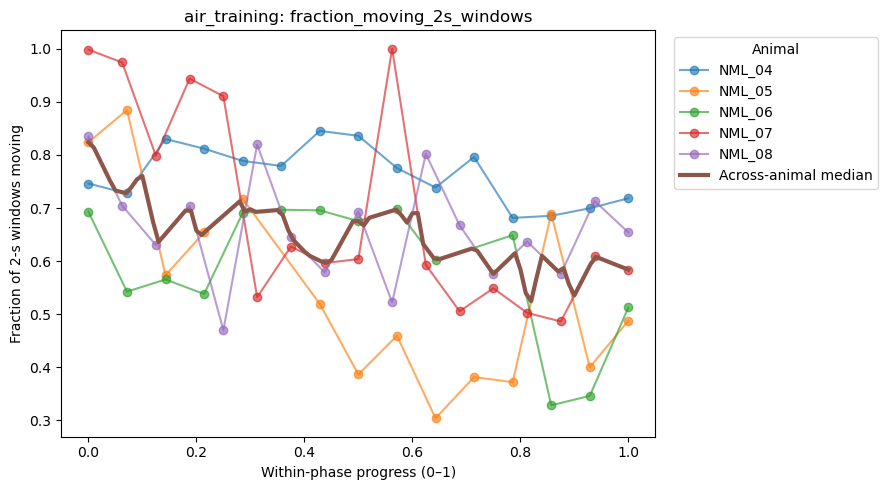

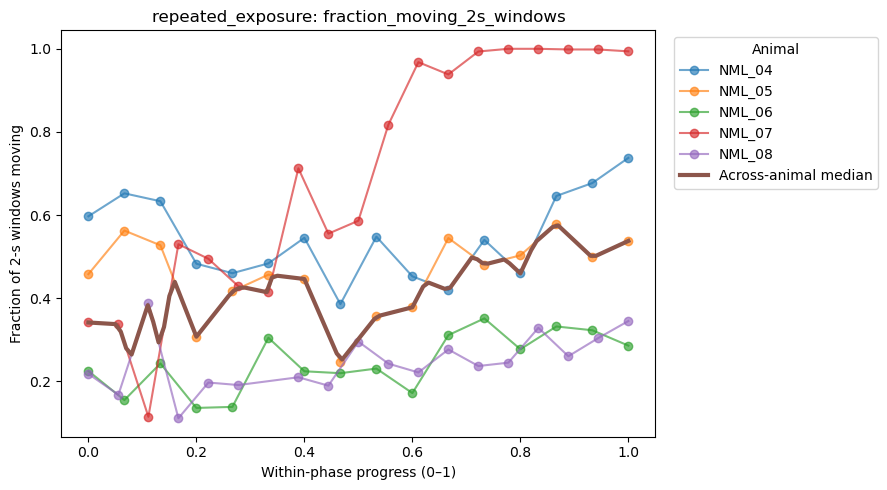

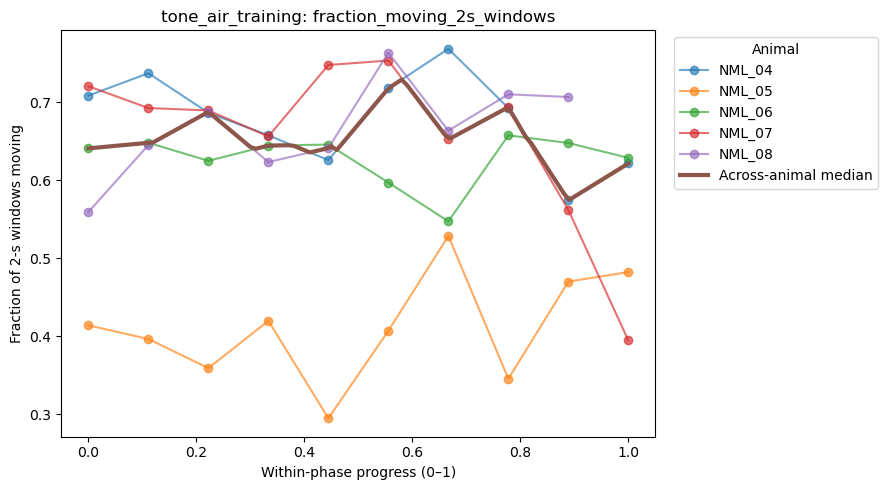

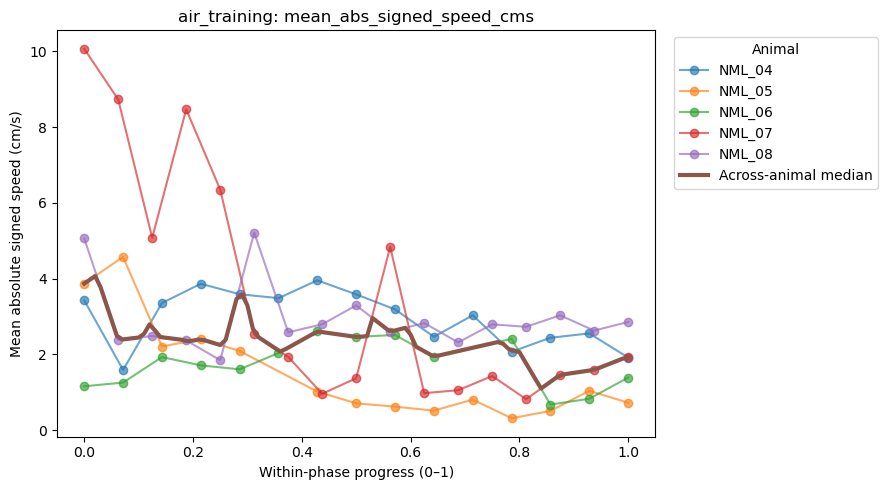

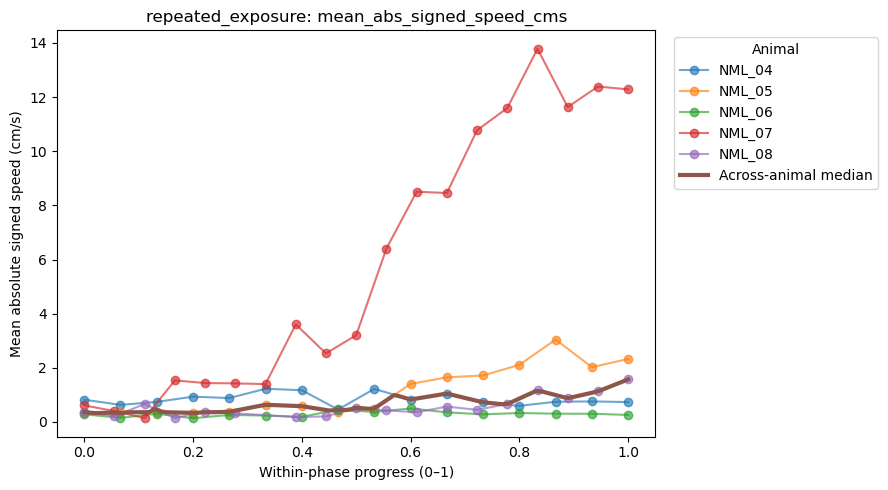

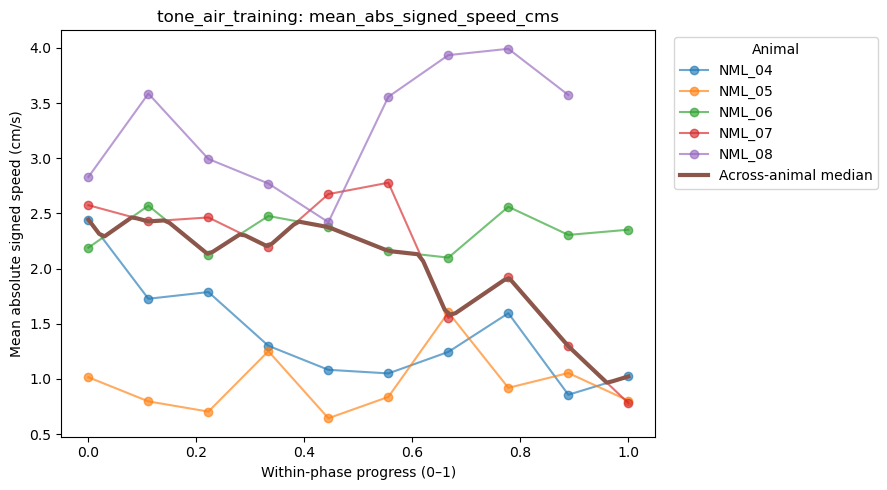

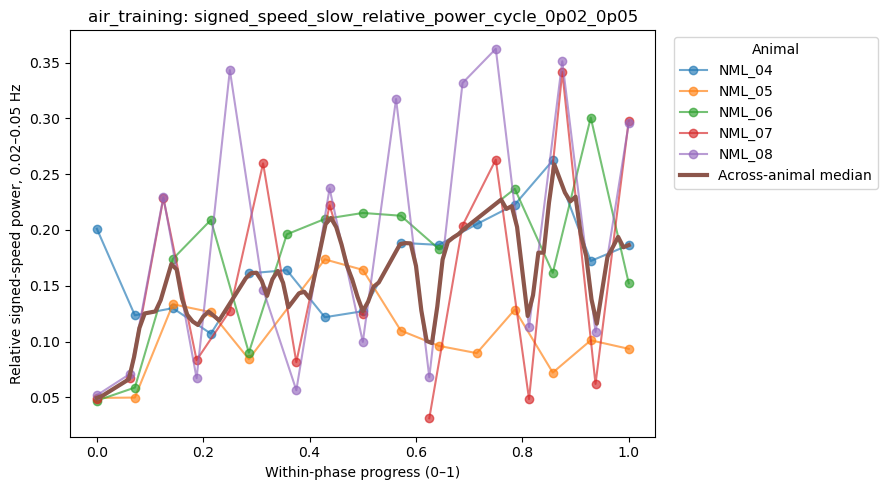

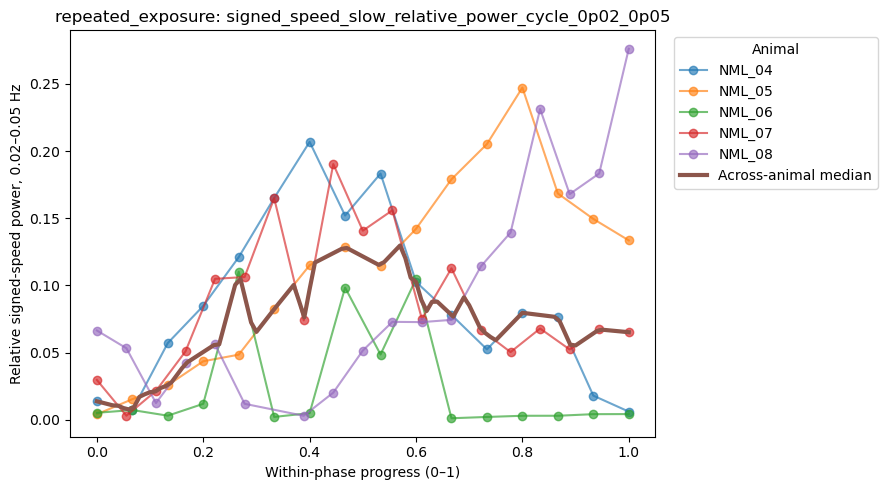

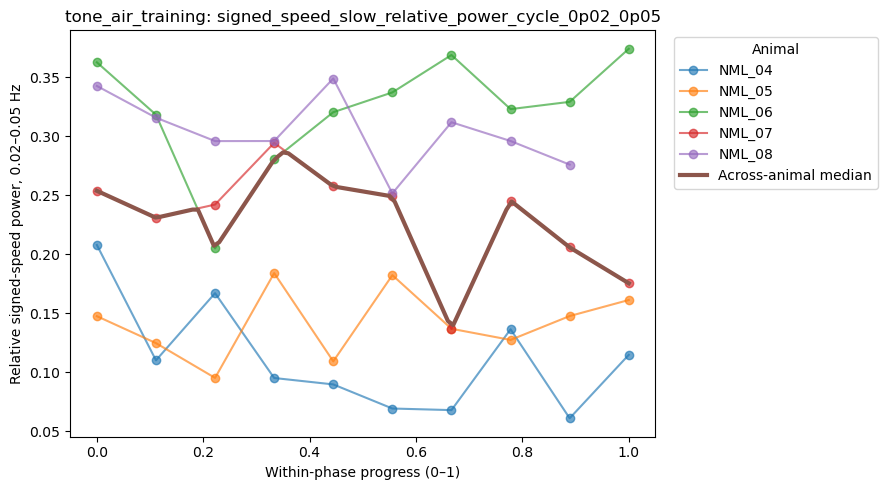

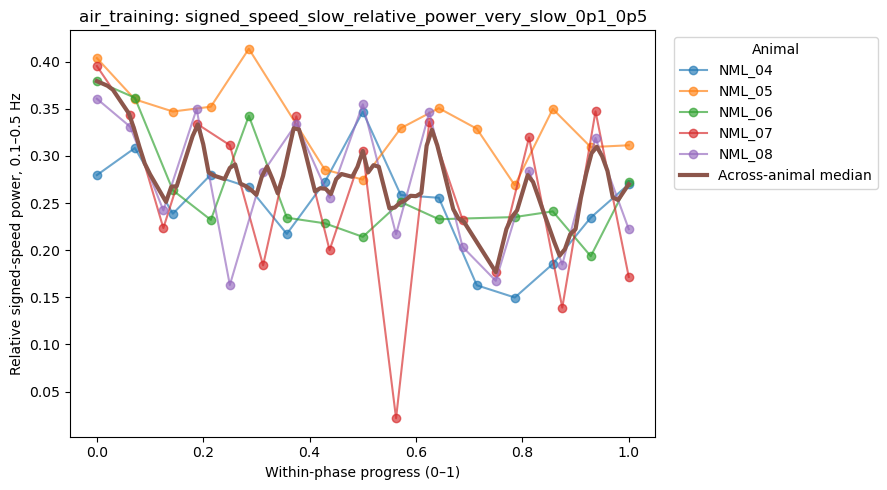

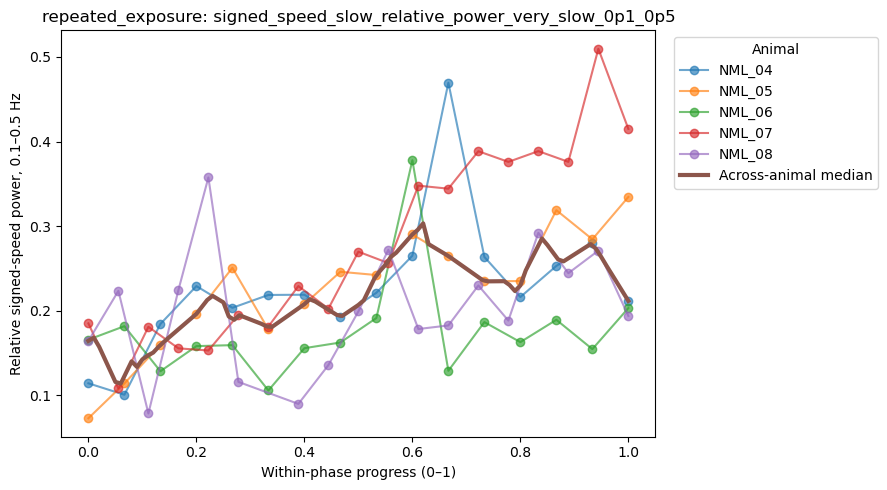

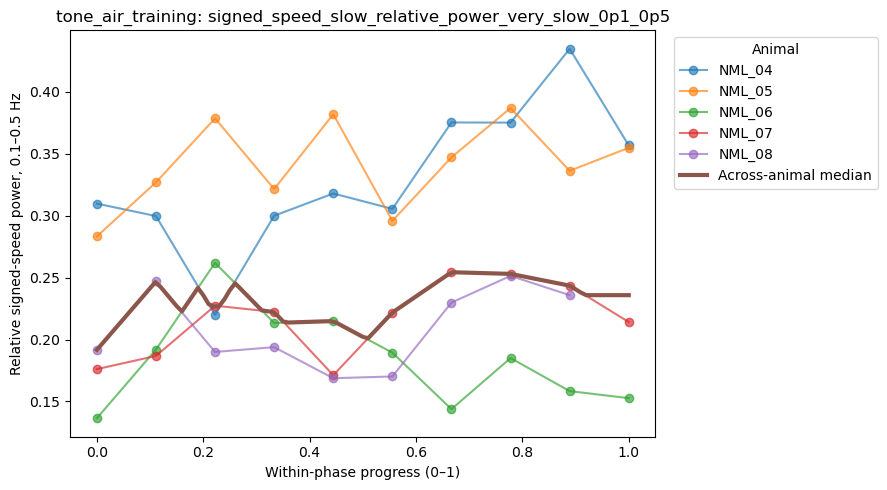

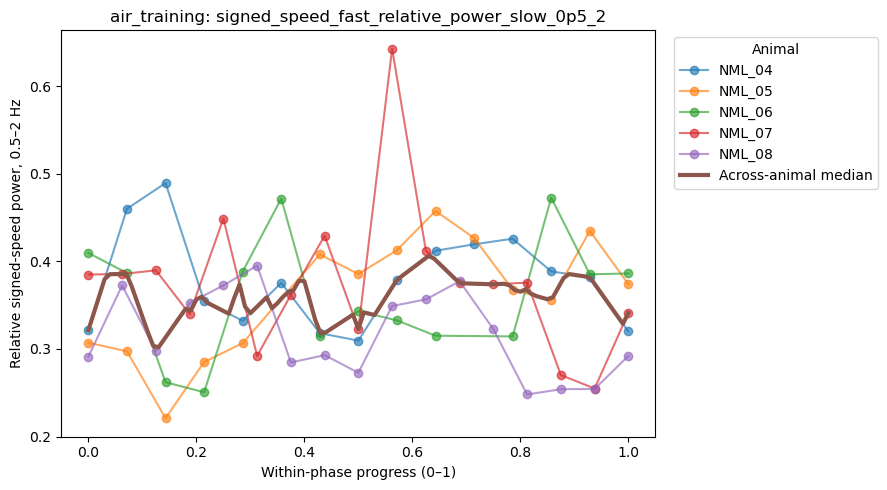

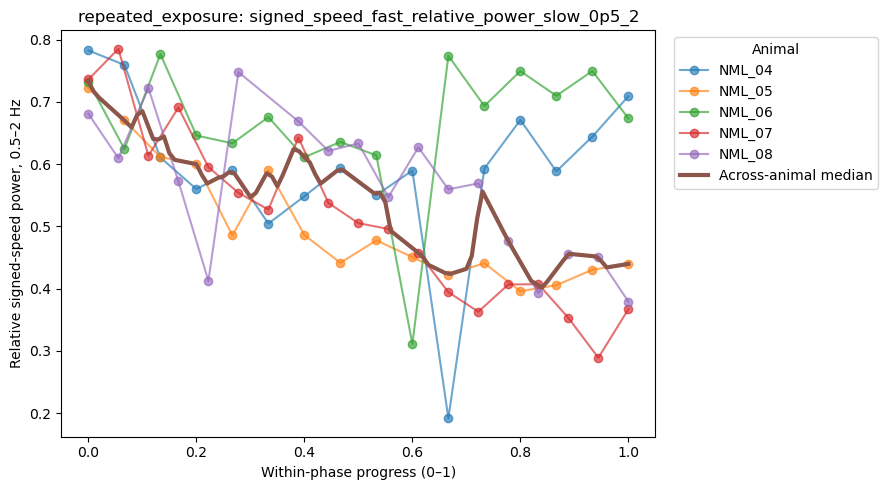

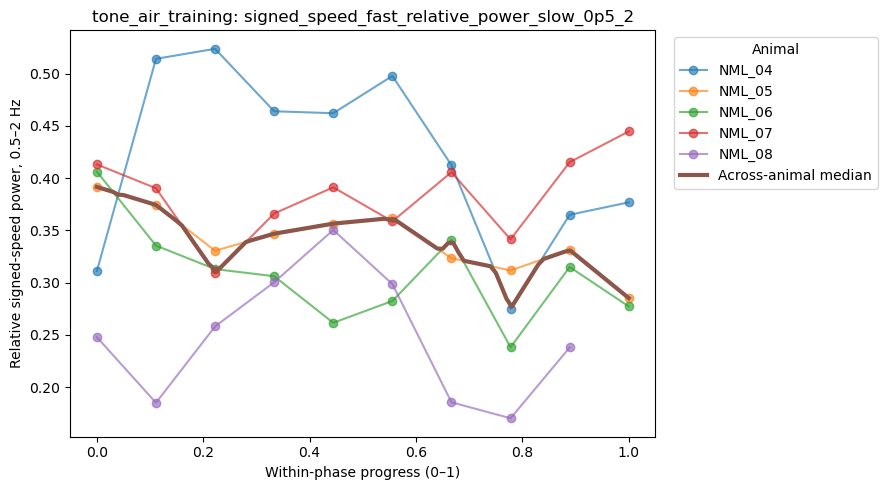

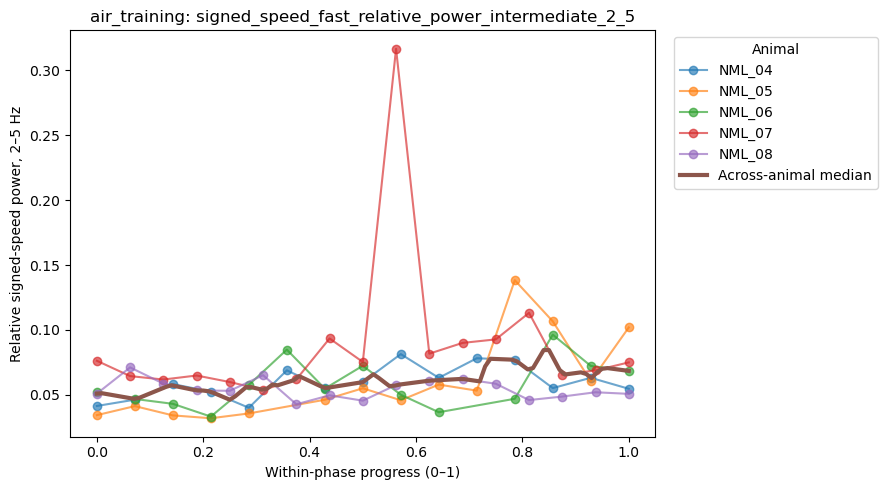

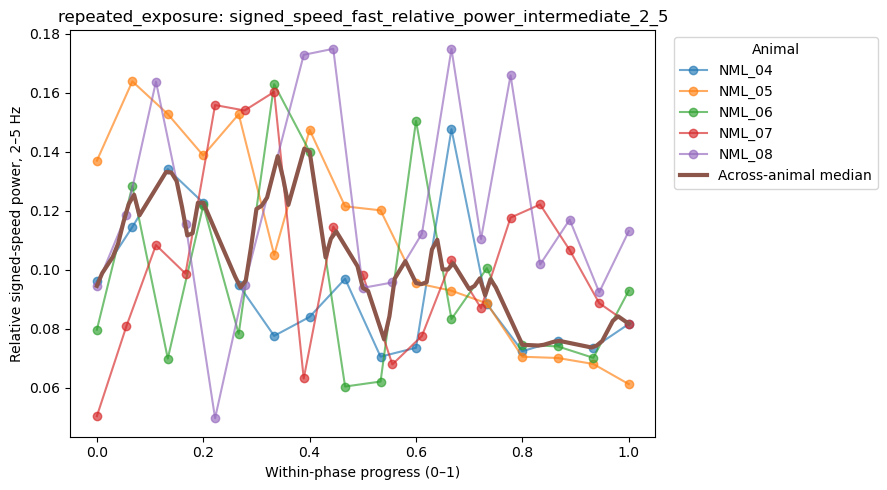

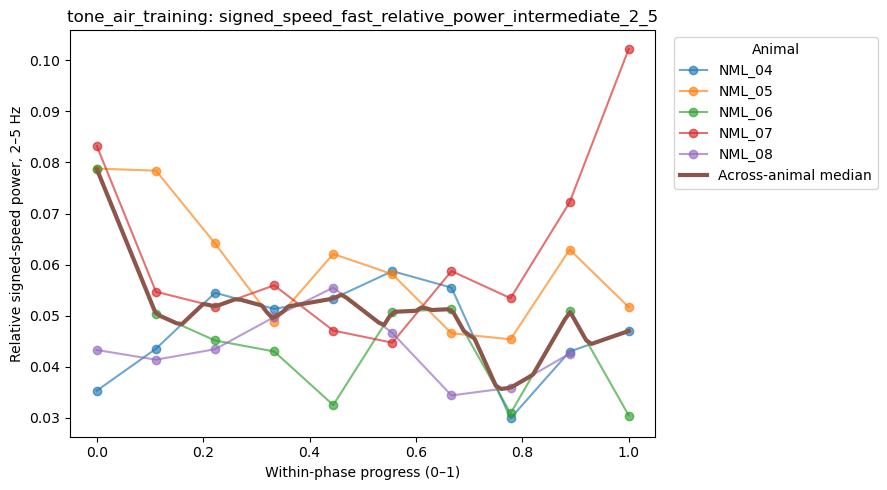

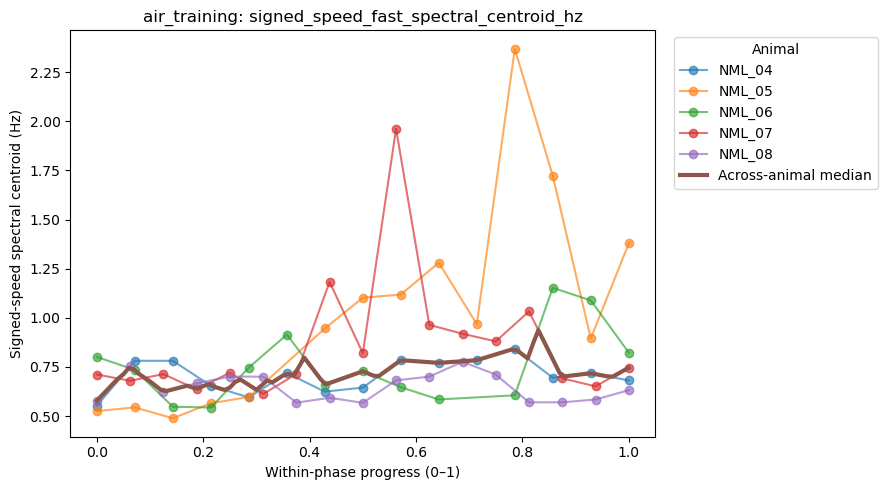

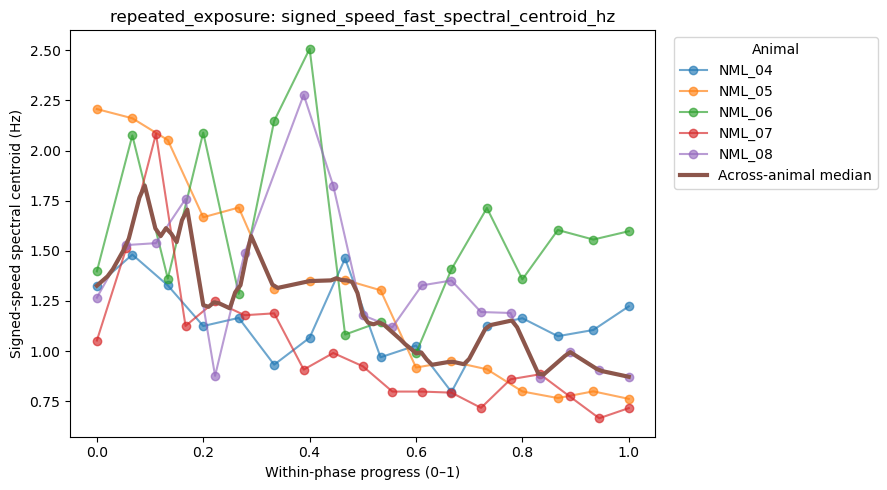

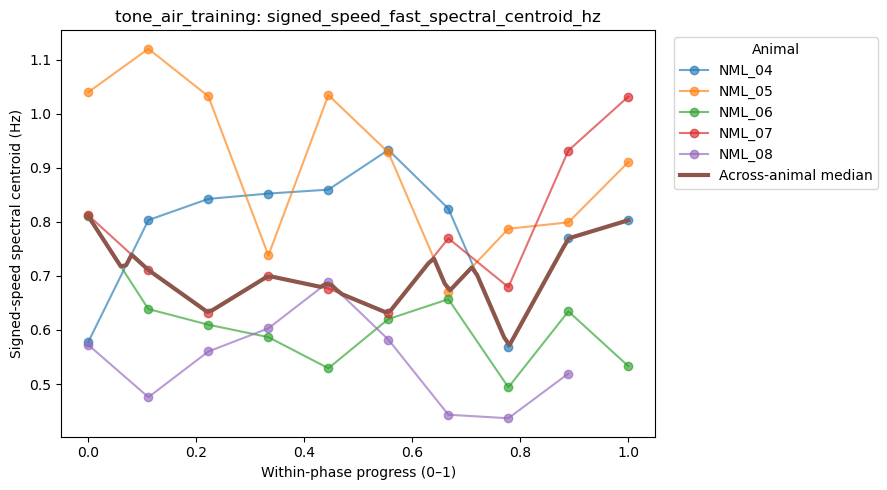

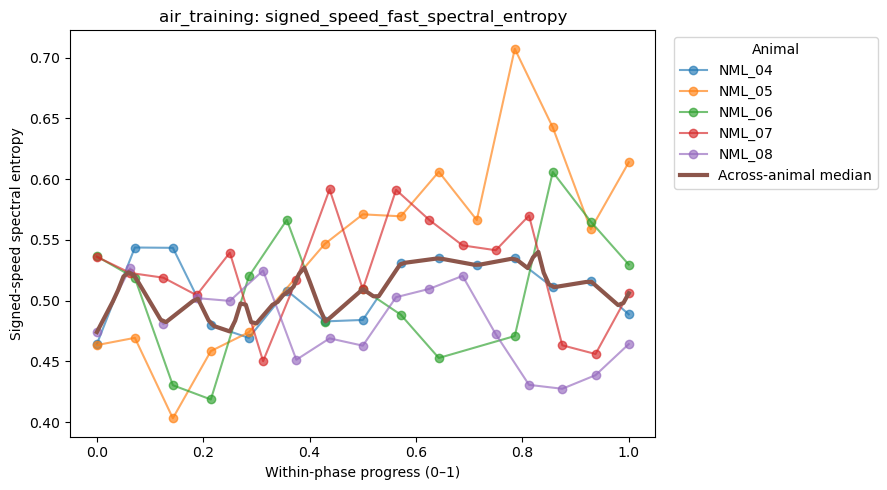

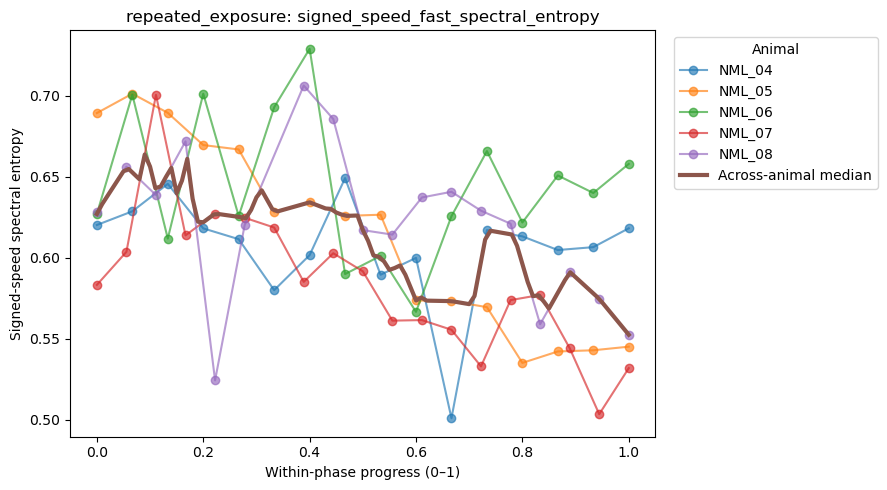

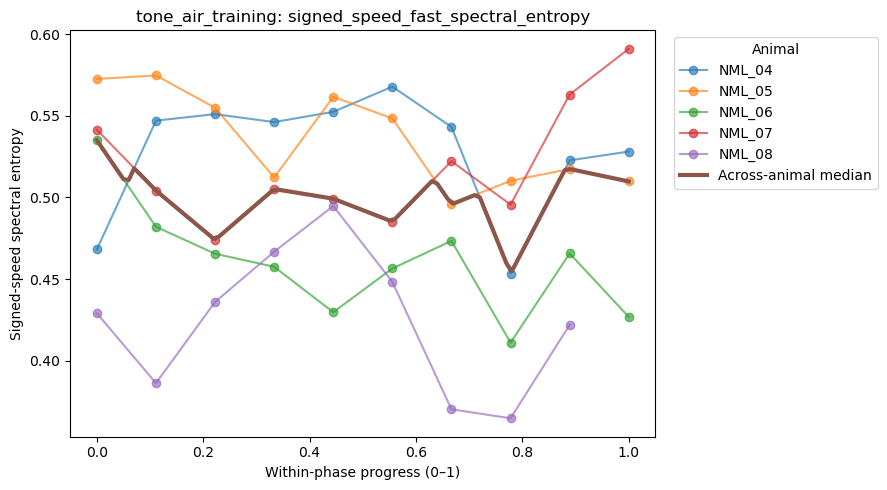

In [17]:
features_to_plot = [
    ("fraction_moving_2s_windows", "Fraction of 2-s windows moving"),
    ("mean_abs_signed_speed_cms", "Mean absolute signed speed (cm/s)"),
    (
        "signed_speed_slow_relative_power_cycle_0p02_0p05",
        "Relative signed-speed power, 0.02–0.05 Hz",
    ),
    (
        "signed_speed_slow_relative_power_very_slow_0p1_0p5",
        "Relative signed-speed power, 0.1–0.5 Hz",
    ),
    (
        "signed_speed_fast_relative_power_slow_0p5_2",
        "Relative signed-speed power, 0.5–2 Hz",
    ),
    (
        "signed_speed_fast_relative_power_intermediate_2_5",
        "Relative signed-speed power, 2–5 Hz",
    ),
    (
        "signed_speed_fast_spectral_centroid_hz",
        "Signed-speed spectral centroid (Hz)",
    ),
    (
        "signed_speed_fast_spectral_entropy",
        "Signed-speed spectral entropy",
    ),
]

for feature, ylabel in features_to_plot:
    plot_feature_by_phase_progress(
        analysis_df,
        feature=feature,
        ylabel=ylabel,
    )

## 13. Equal-animal PSD summaries

The PSD is first summarized within each animal-phase and only then summarized across animals.

In [18]:
animal_phase_psd_df = (
    analysis_psd_df
    .groupby(
        ["animal", "phase", "signal", "resolution", "frequency_hz"],
        as_index=False,
    )
    .agg(
        power=("power", "median"),
        relative_power_density=("relative_power_density", "median"),
    )
)

animal_phase_psd_path = (
    whole_session_output_dir
    / "animal_phase_psd_median.csv"
)

animal_phase_psd_df.to_csv(animal_phase_psd_path, index=False)
print("Saved:", animal_phase_psd_path)

Saved: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/animal_phase_psd_median.csv


In [19]:
def plot_equal_animal_phase_psd(
    animal_phase_psd,
    signal,
    resolution,
    relative=False,
):
    value_column = "relative_power_density" if relative else "power"

    subset = animal_phase_psd.loc[
        (animal_phase_psd["signal"] == signal)
        & (animal_phase_psd["resolution"] == resolution)
    ].copy()

    saved = []

    for phase, phase_df in subset.groupby("phase"):
        fig, ax = plt.subplots(figsize=(9, 5))

        for animal, animal_df in phase_df.groupby("animal"):
            animal_df = animal_df.sort_values("frequency_hz")
            plot_method = ax.plot if relative else ax.semilogy
            plot_method(
                animal_df["frequency_hz"],
                animal_df[value_column],
                alpha=0.55,
                label=animal,
            )

        group_median = (
            phase_df
            .groupby("frequency_hz", as_index=False)[value_column]
            .median()
        )

        plot_method = ax.plot if relative else ax.semilogy
        plot_method(
            group_median["frequency_hz"],
            group_median[value_column],
            linewidth=3,
            label="Across-animal median",
        )

        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel(
            "Relative power density"
            if relative
            else "PSD [(cm/s)²/Hz]"
        )
        ax.set_title(f"{phase}: {signal}, {resolution} PSD")
        ax.legend(title="Animal", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout()

        path = figure_dir / (
            f"{phase}_{signal}_{resolution}_"
            f"{'relative' if relative else 'absolute'}_psd.png"
        )
        fig.savefig(path, dpi=200)
        saved.append(path)
        plt.show()
        plt.close(fig)

    return saved

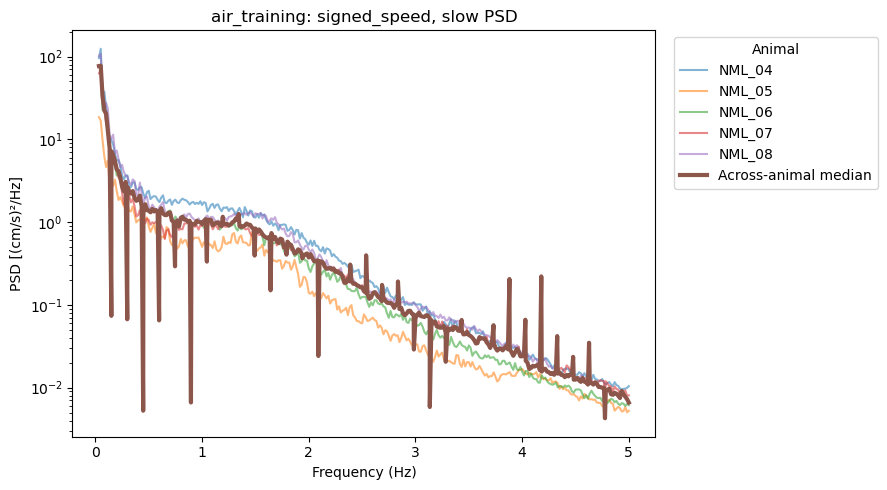

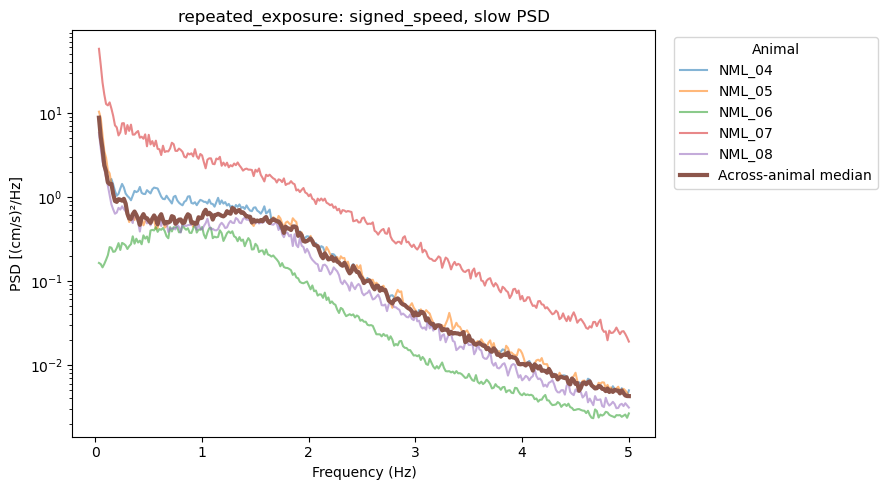

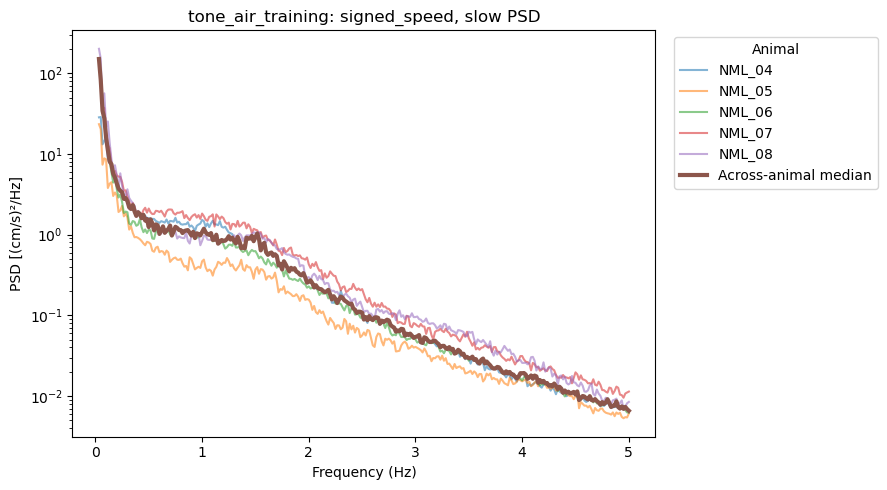

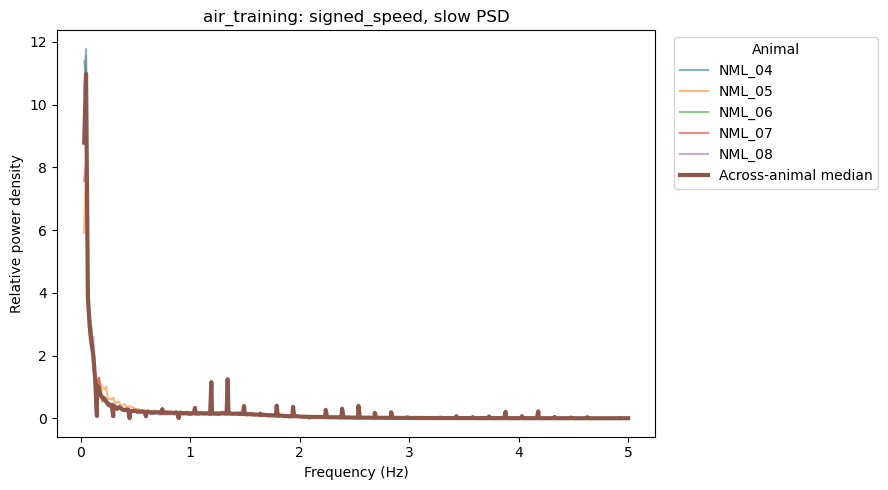

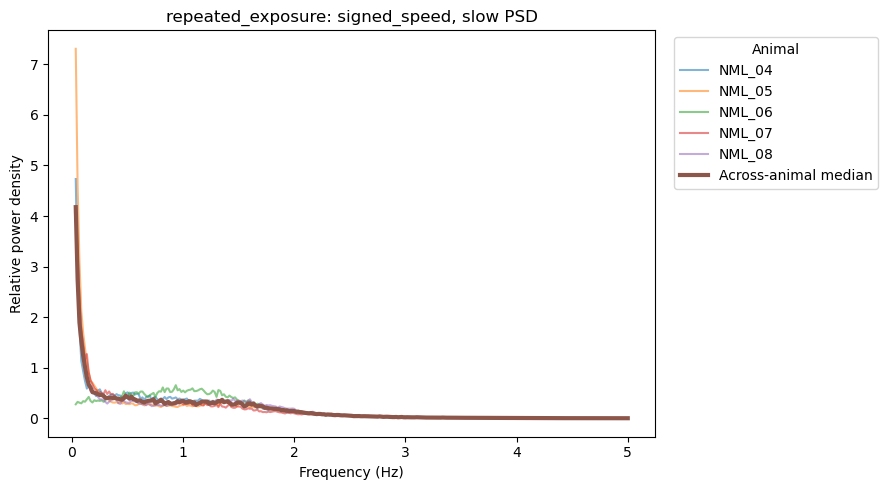

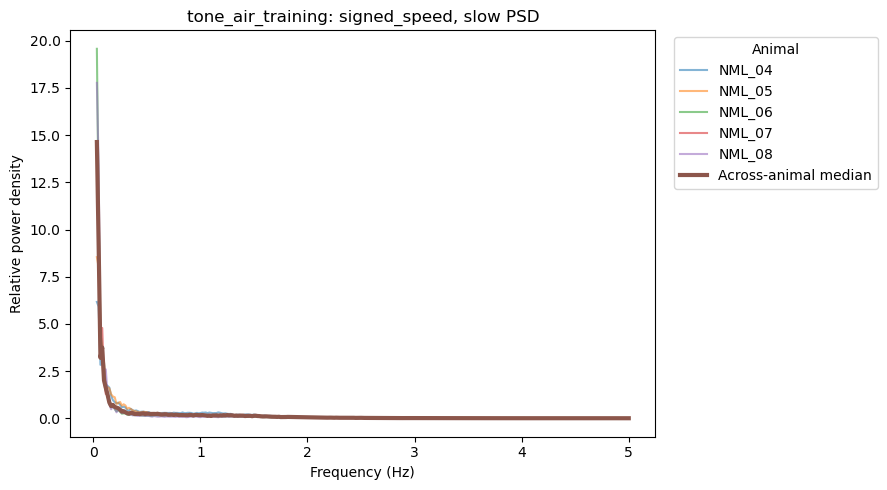

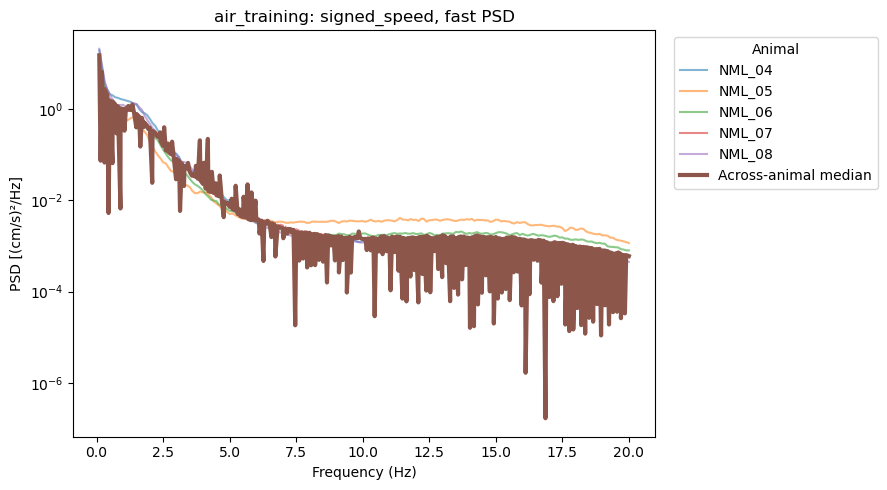

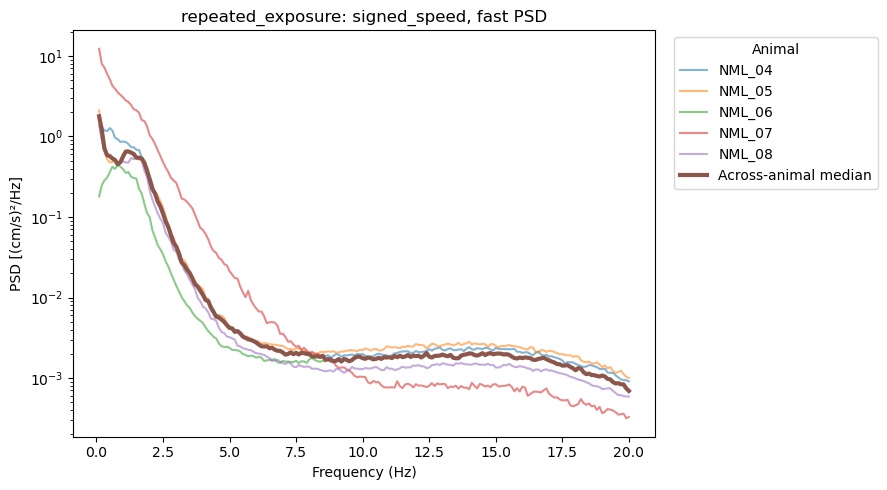

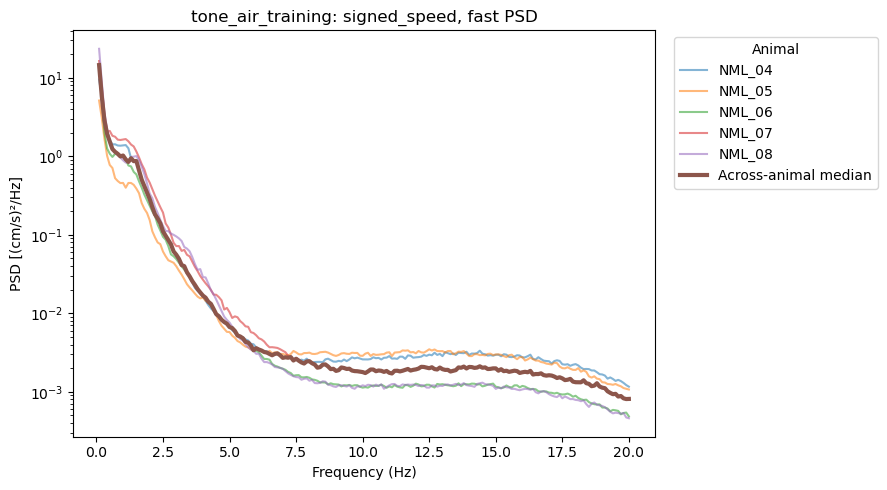

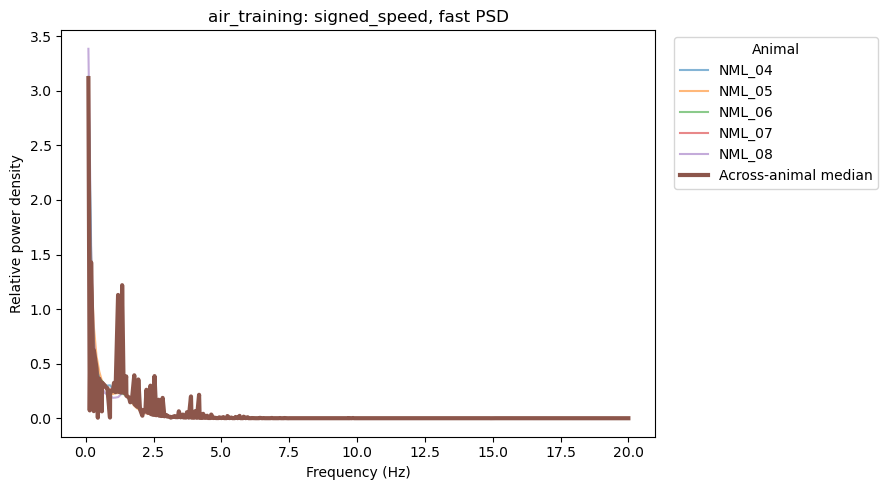

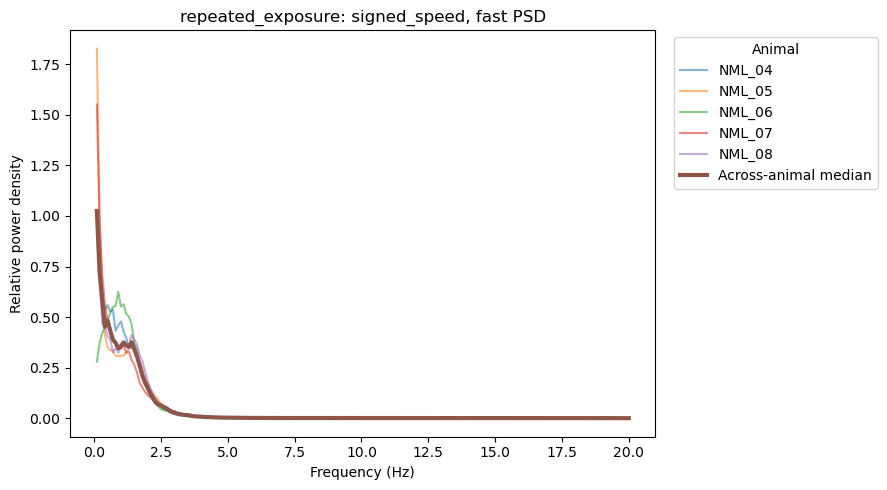

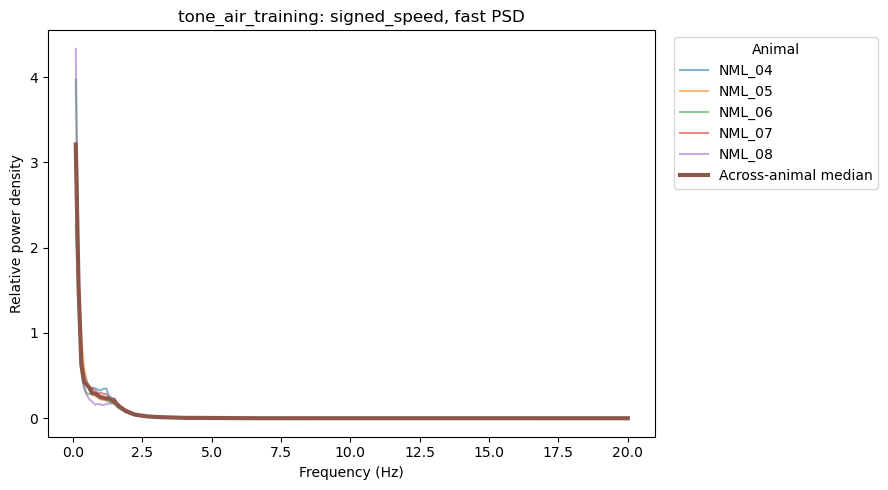

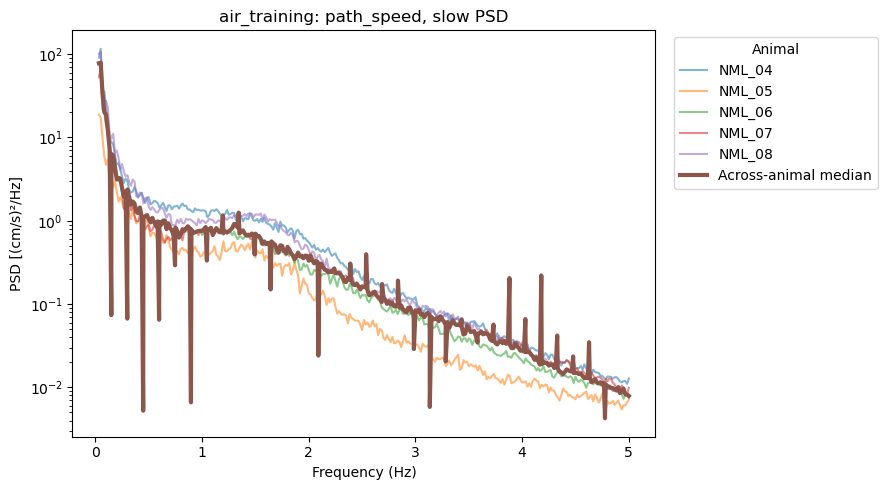

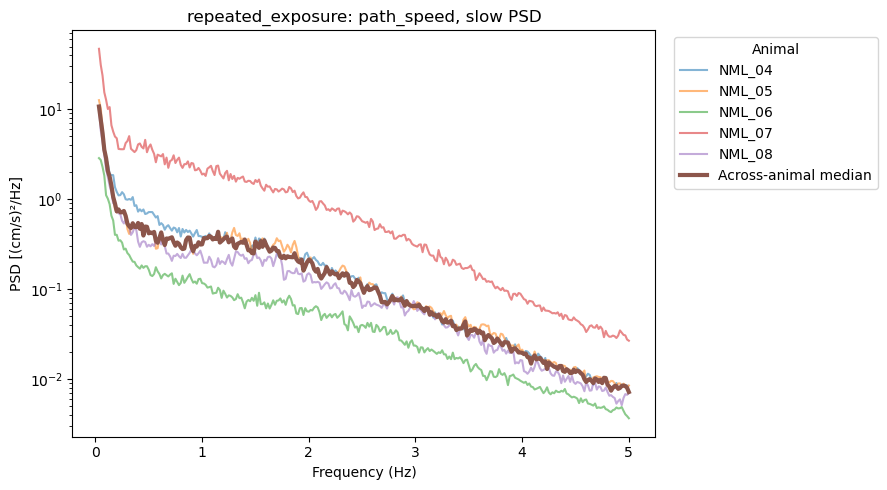

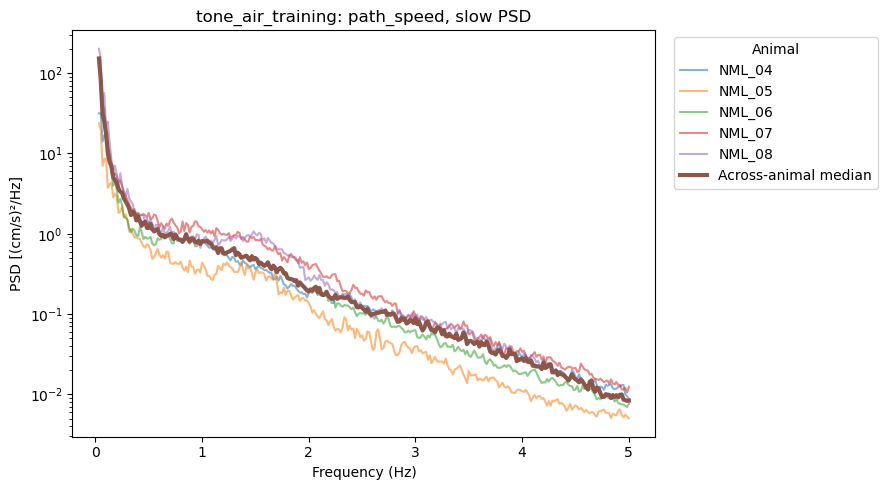

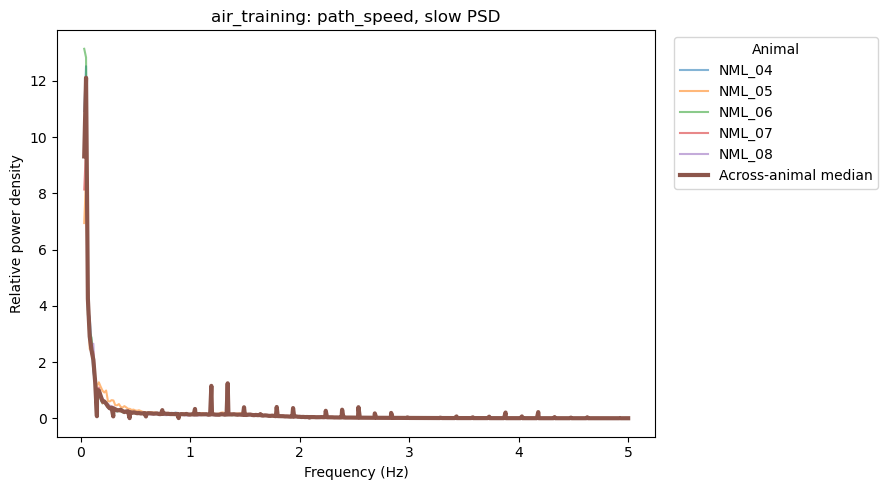

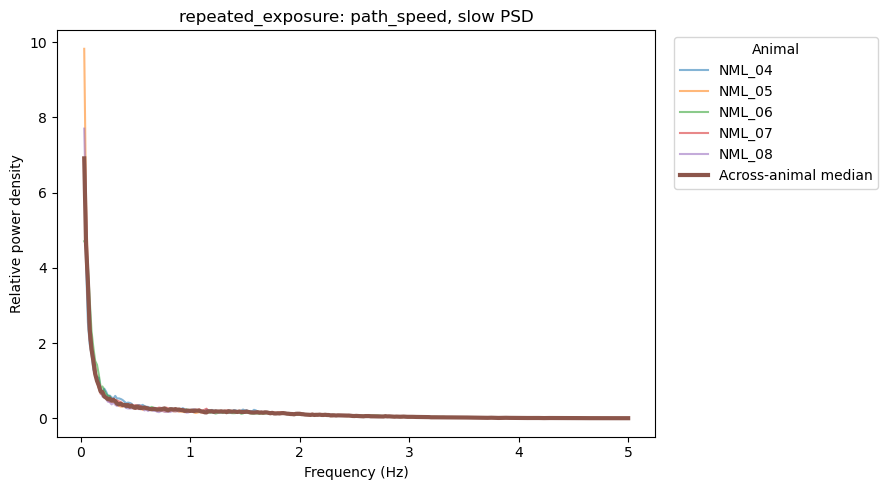

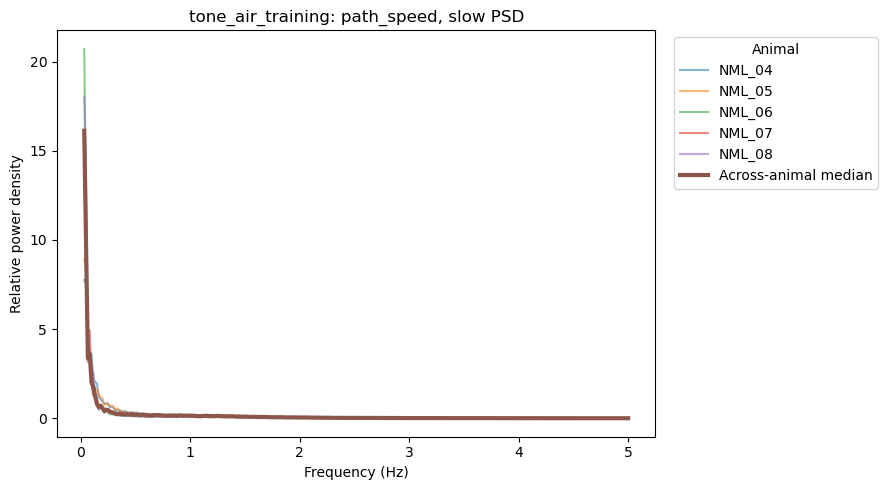

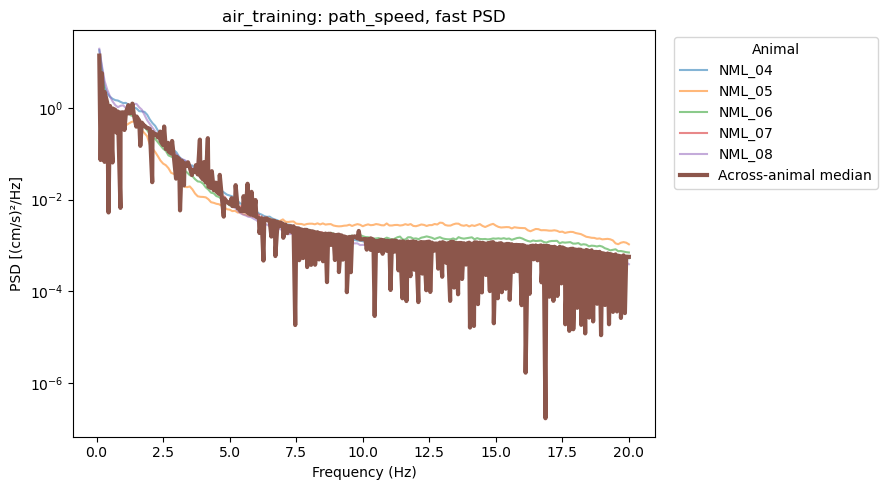

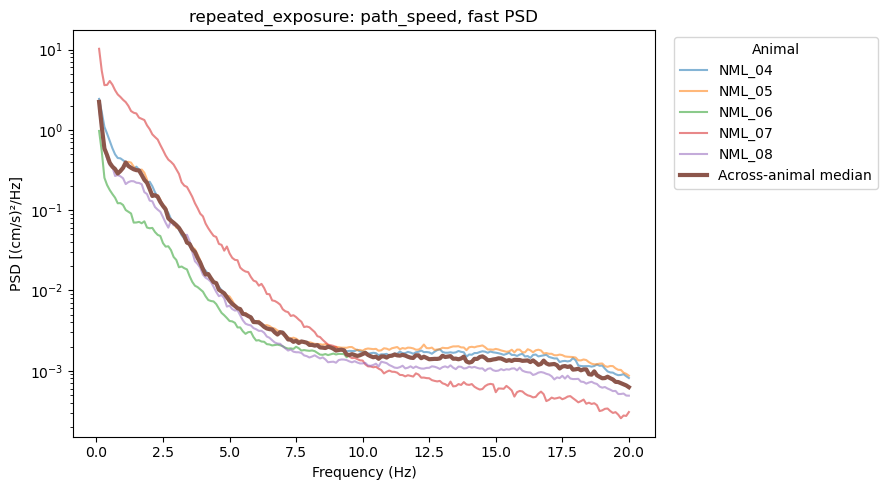

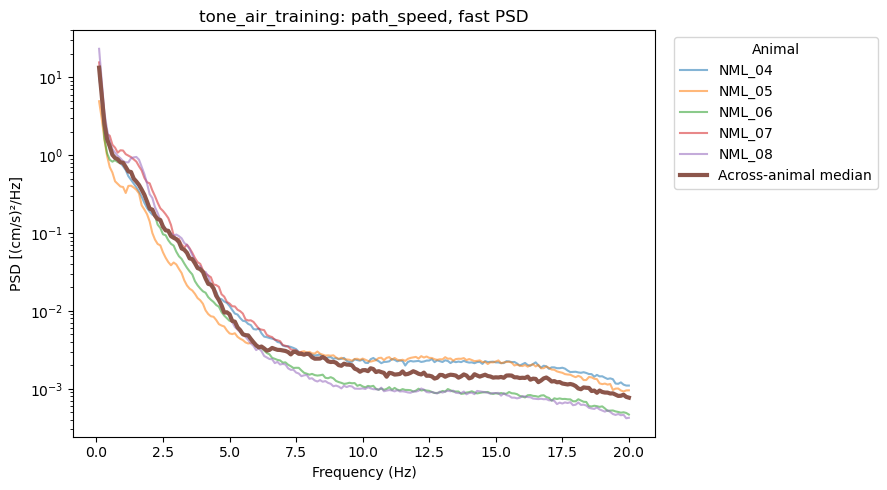

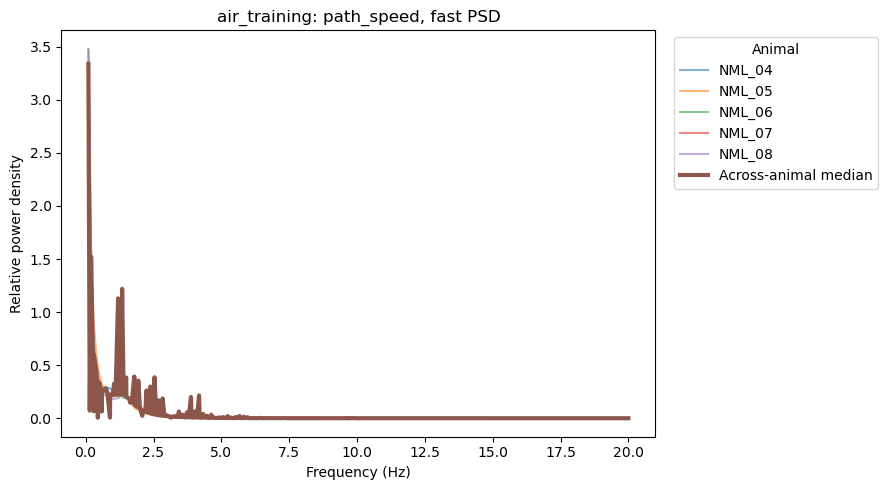

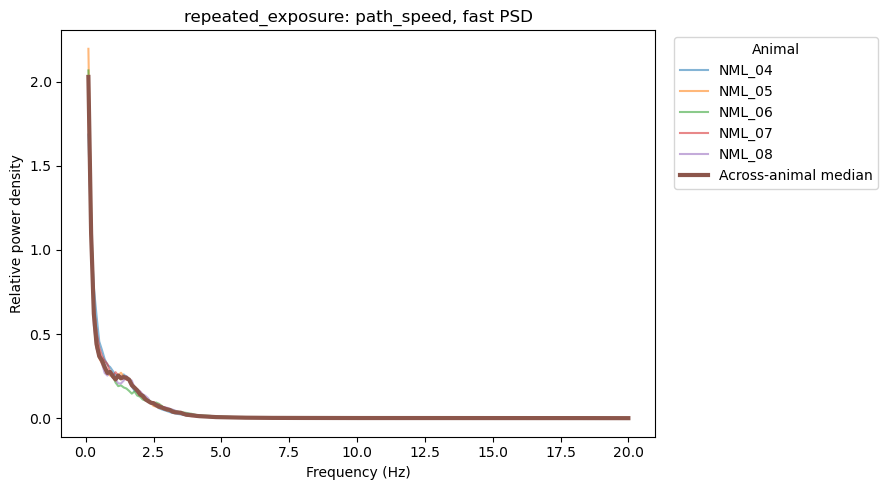

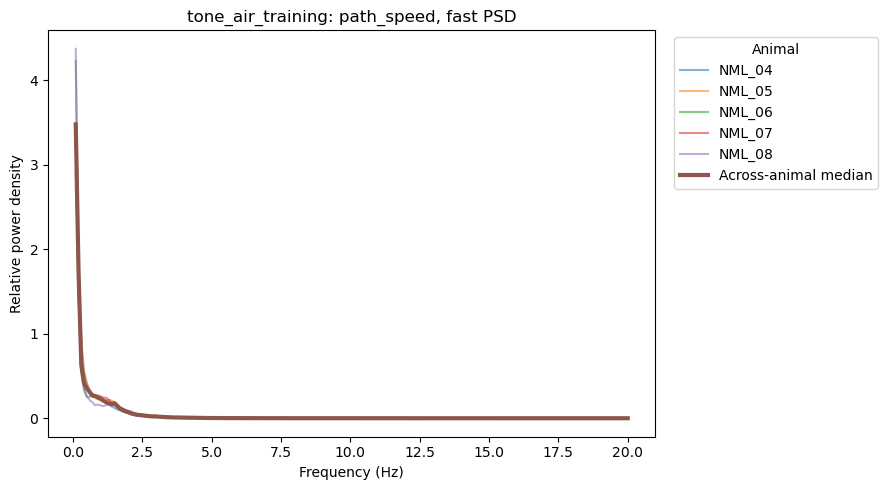

In [20]:
for signal in ["signed_speed", "path_speed"]:
    for resolution in ["slow", "fast"]:
        plot_equal_animal_phase_psd(
            animal_phase_psd_df,
            signal=signal,
            resolution=resolution,
            relative=False,
        )
        plot_equal_animal_phase_psd(
            animal_phase_psd_df,
            signal=signal,
            resolution=resolution,
            relative=True,
        )

## 14. Animal-level within-phase slopes

Each animal contributes one slope per phase and feature. This is the primary whole-session experience screen.

In [21]:
def calculate_animal_phase_slopes(session_df, features):
    rows = []

    for (animal, phase), group_df in session_df.groupby(["animal", "phase"]):
        group_df = group_df.sort_values("phase_progress_0_1")
        x = group_df["phase_progress_0_1"].to_numpy(dtype=float)

        for feature in features:
            y = group_df[feature].to_numpy(dtype=float)
            finite = np.isfinite(x) & np.isfinite(y)

            if np.count_nonzero(finite) < 3:
                continue

            slope, intercept = np.polyfit(x[finite], y[finite], deg=1)
            rows.append(
                {
                    "animal": animal,
                    "phase": phase,
                    "feature": feature,
                    "n_sessions": int(np.count_nonzero(finite)),
                    "slope_per_phase_progress": slope,
                    "intercept": intercept,
                }
            )

    return pd.DataFrame(rows)

In [22]:
slope_features = [
    "fraction_moving_2s_windows",
    "mean_abs_signed_speed_cms",
    "signed_speed_slow_relative_power_cycle_0p02_0p05",
    "signed_speed_slow_relative_power_cycle_0p05_0p1",
    "signed_speed_slow_relative_power_very_slow_0p1_0p5",
    "signed_speed_fast_relative_power_slow_0p5_2",
    "signed_speed_fast_relative_power_intermediate_2_5",
    "signed_speed_fast_spectral_centroid_hz",
    "signed_speed_fast_spectral_entropy",
    "path_speed_fast_relative_power_slow_0p5_2",
    "path_speed_fast_relative_power_intermediate_2_5",
    "path_speed_fast_spectral_centroid_hz",
    "path_speed_fast_spectral_entropy",
]

animal_phase_slopes_df = calculate_animal_phase_slopes(
    analysis_df,
    slope_features,
)

slope_path = whole_session_output_dir / "animal_phase_feature_slopes.csv"
animal_phase_slopes_df.to_csv(slope_path, index=False)
print("Saved:", slope_path)
display(animal_phase_slopes_df.head())

Saved: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/animal_phase_feature_slopes.csv


,animal,phase,feature,n_sessions,slope_per_phase_progress,intercept
0,NML_04,air_training,fraction_moving_2s_windows,15,-0.086836,0.807381
1,NML_04,air_training,mean_abs_signed_speed_cms,15,-1.051987,3.492838
2,NML_04,air_training,signed_speed_slow_relative_power_cycle_0p02_0p05,15,0.077969,0.131647
3,NML_04,air_training,signed_speed_slow_relative_power_cycle_0p05_0p1,15,0.059062,0.279906
4,NML_04,air_training,signed_speed_slow_relative_power_very_slow_0p1...,15,-0.077449,0.287206


In [23]:
slope_consistency_df = (
    animal_phase_slopes_df
    .groupby(["phase", "feature"], as_index=False)
    .agg(
        n_animals=("animal", "nunique"),
        median_slope=("slope_per_phase_progress", "median"),
        minimum_slope=("slope_per_phase_progress", "min"),
        maximum_slope=("slope_per_phase_progress", "max"),
        positive_animals=(
            "slope_per_phase_progress",
            lambda values: int(np.sum(np.asarray(values) > 0)),
        ),
        negative_animals=(
            "slope_per_phase_progress",
            lambda values: int(np.sum(np.asarray(values) < 0)),
        ),
    )
)

slope_consistency_path = (
    whole_session_output_dir
    / "animal_phase_slope_consistency.csv"
)

slope_consistency_df.to_csv(slope_consistency_path, index=False)
print("Saved:", slope_consistency_path)
display(slope_consistency_df.sort_values(["feature", "phase"]))

Saved: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/animal_phase_slope_consistency.csv


,phase,feature,n_animals,median_slope,minimum_slope,maximum_slope,positive_animals,negative_animals
0,air_training,fraction_moving_2s_windows,5,-0.190536,-0.437093,-0.071579,0,5
13,repeated_exposure,fraction_moving_2s_windows,5,0.104098,0.054754,0.862285,5,0
26,tone_air_training,fraction_moving_2s_windows,5,-0.015705,-0.208979,0.131452,2,3
1,air_training,mean_abs_signed_speed_cms,5,-1.051987,-7.729625,-0.220672,0,5
14,repeated_exposure,mean_abs_signed_speed_cms,5,0.909286,-0.109229,15.095900,4,1
27,tone_air_training,mean_abs_signed_speed_cms,5,0.023553,-1.560247,1.029015,3,2
2,air_training,path_speed_fast_relative_power_intermediate_2_5,5,0.020534,-0.012594,0.052019,4,1
15,repeated_exposure,path_speed_fast_relative_power_intermediate_2_5,5,-0.074402,-0.161780,0.002047,1,4
28,tone_air_training,path_speed_fast_relative_power_intermediate_2_5,5,-0.019780,-0.027901,0.031719,1,4
3,air_training,path_speed_fast_relative_power_slow_0p5_2,5,-0.013231,-0.082150,0.138131,2,3


## 15. Plot animal-level slopes

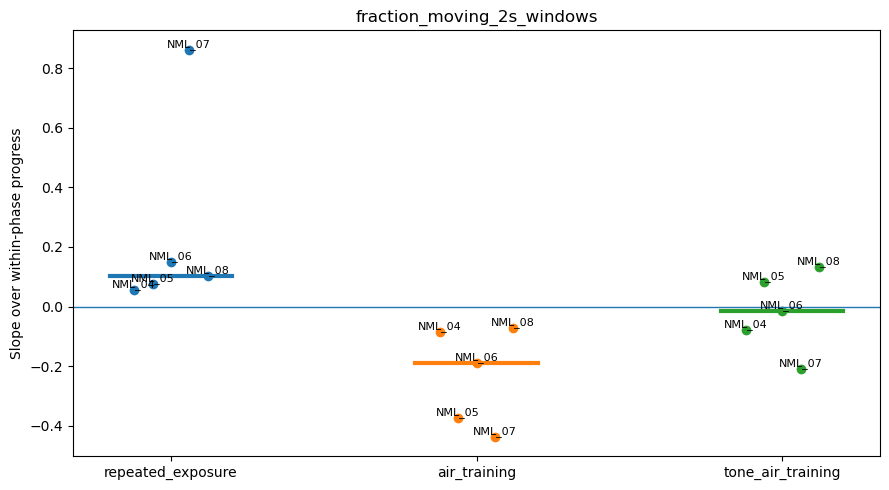

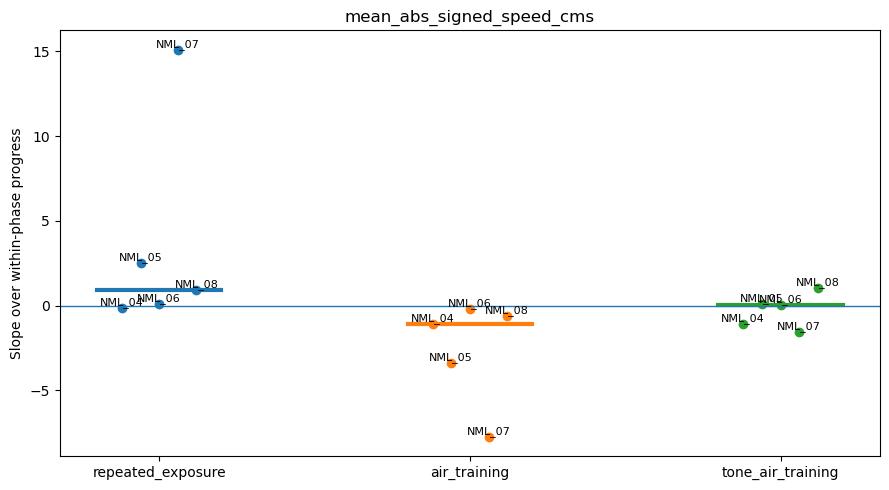

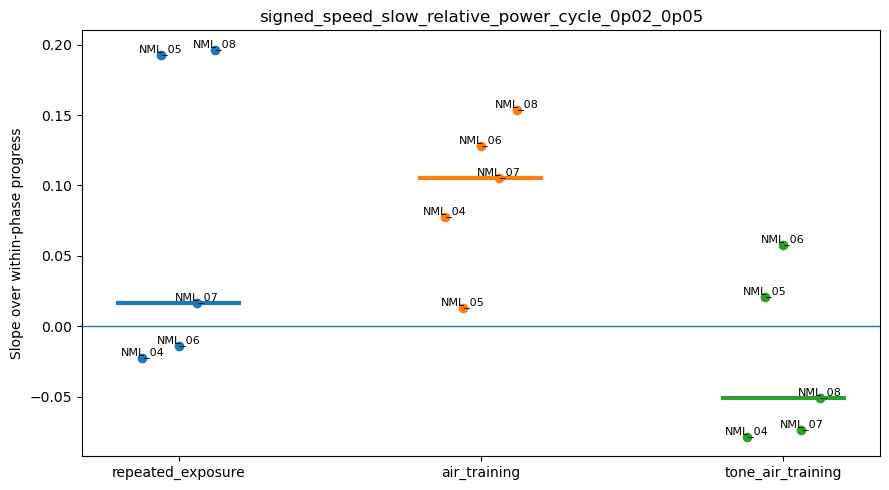

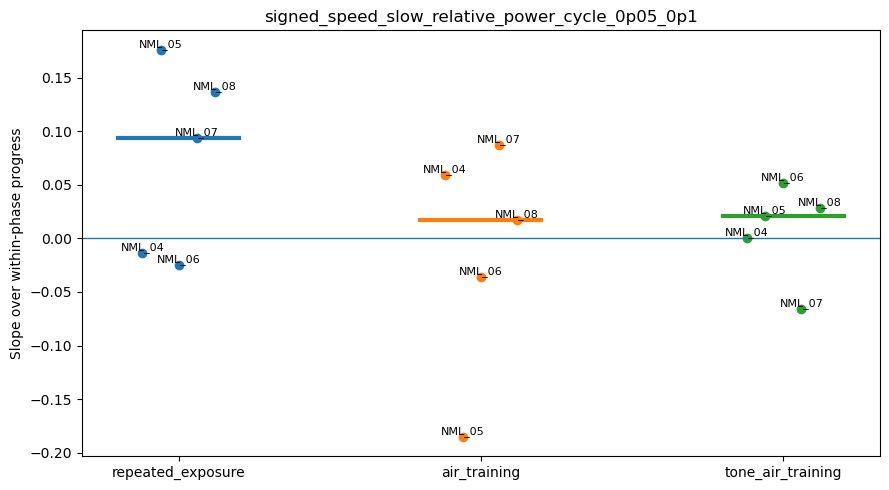

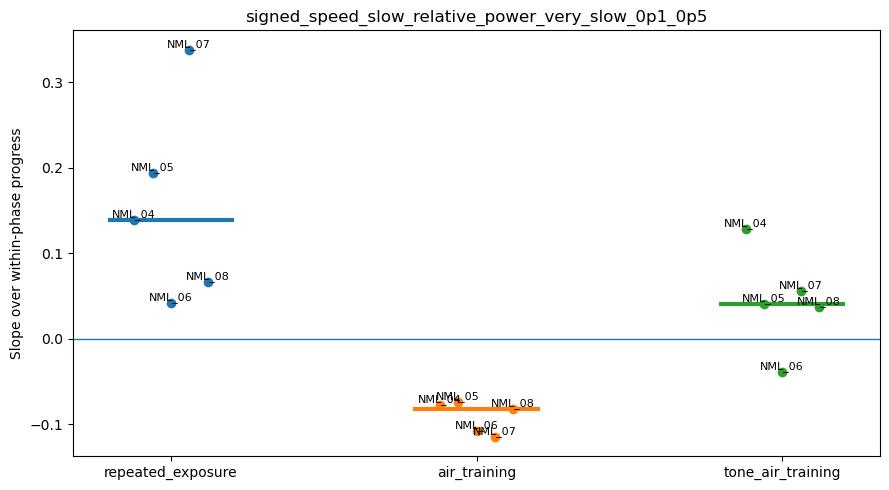

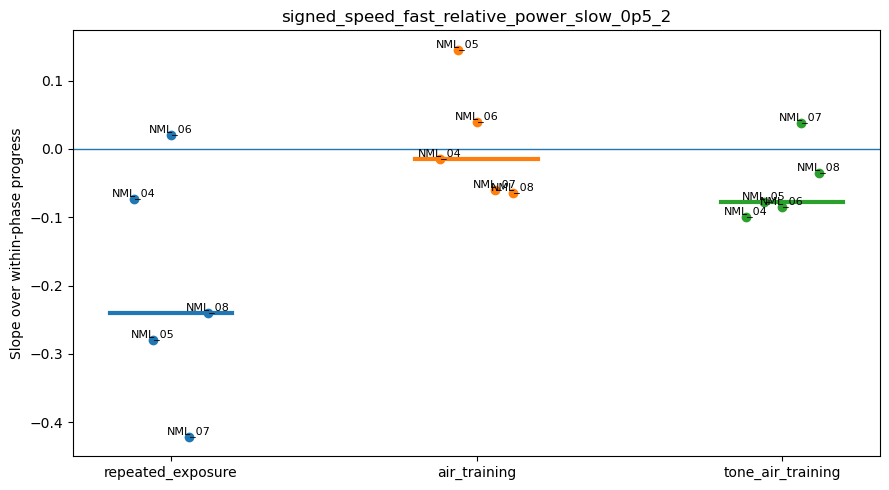

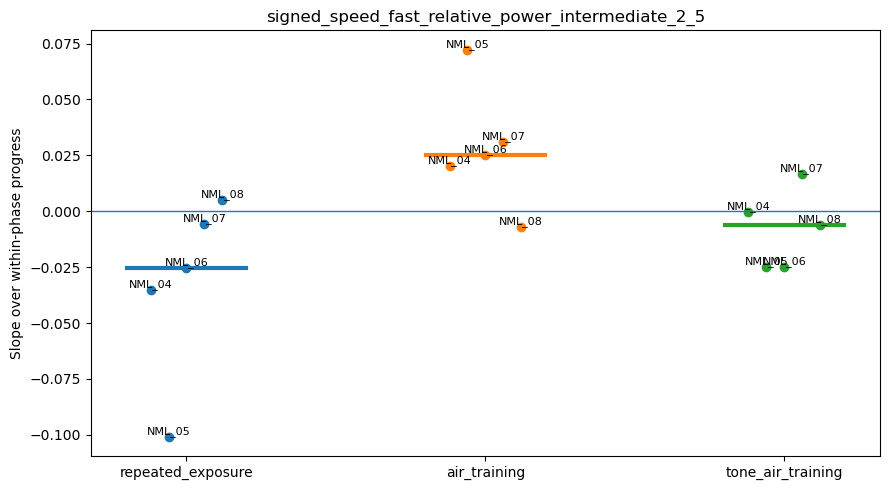

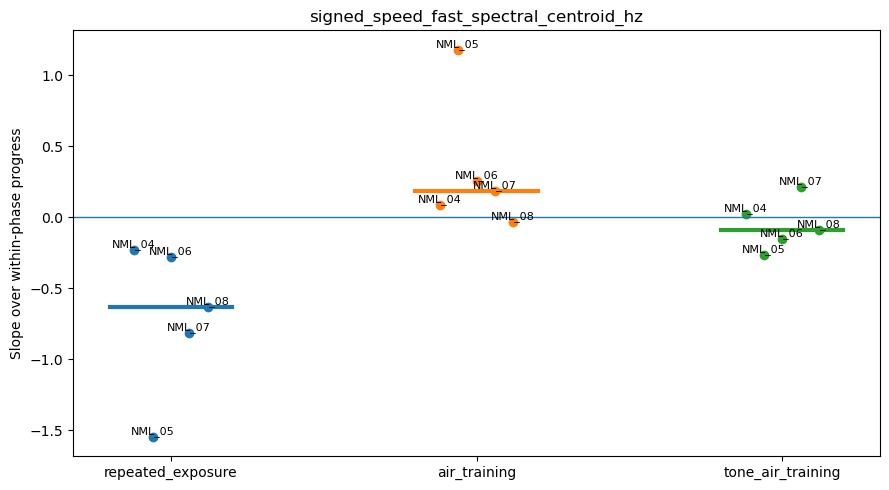

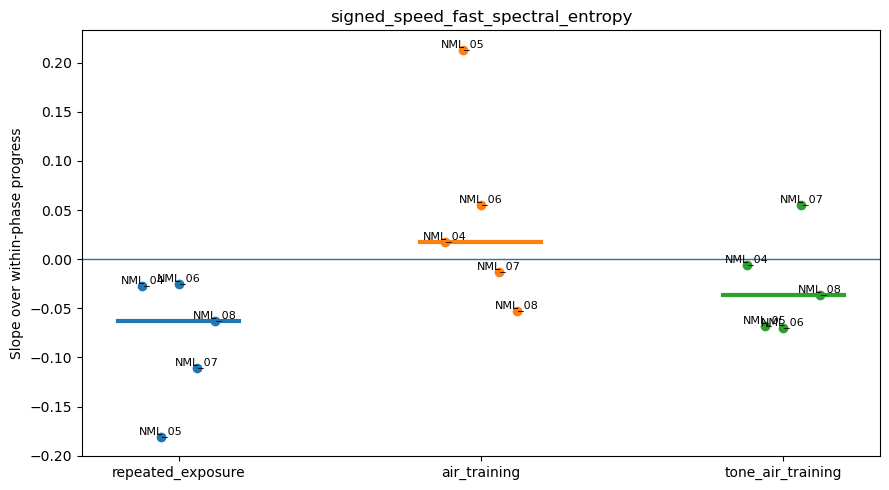

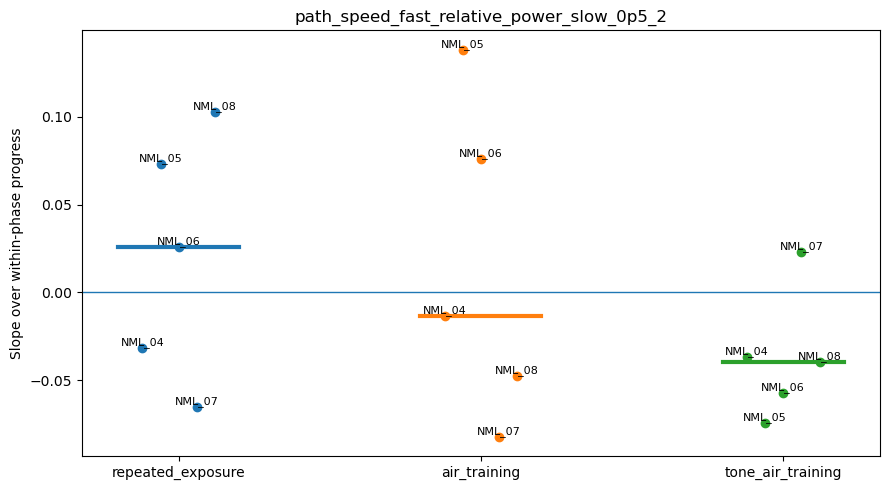

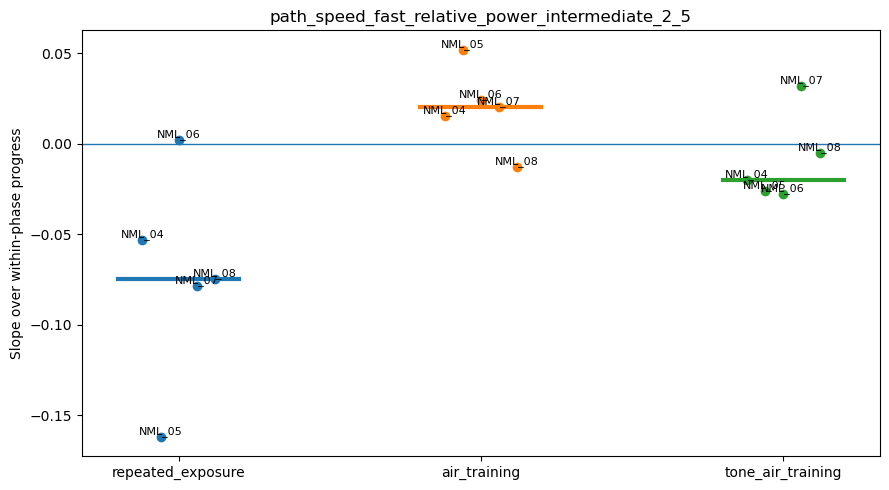

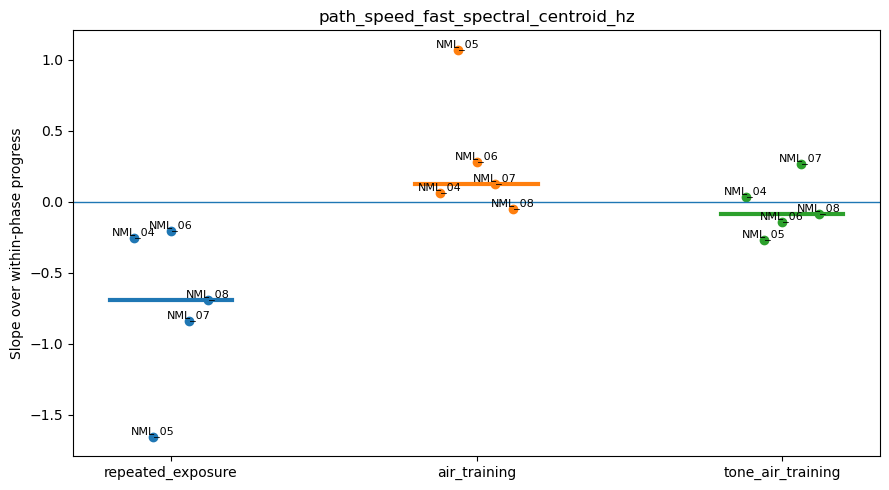

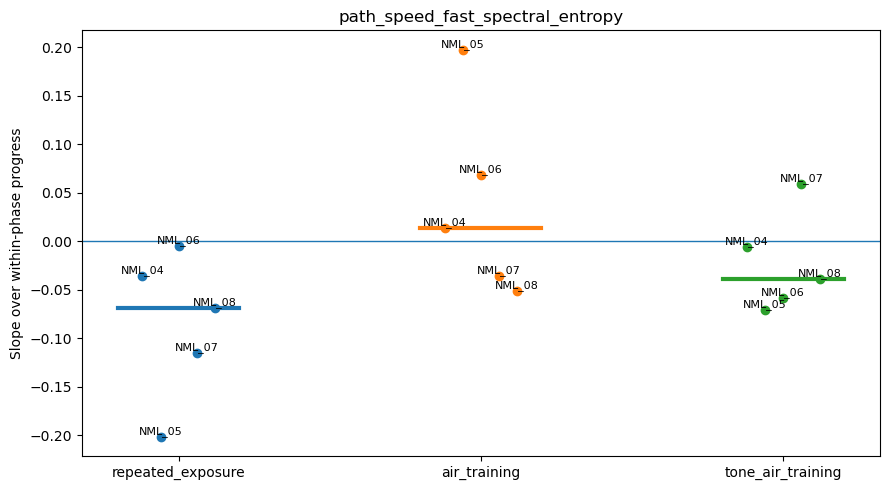

In [24]:
def plot_animal_slopes(slopes_df, feature):
    plot_df = slopes_df.loc[slopes_df["feature"] == feature].copy()
    phases = [
        phase
        for phase in [
            "repeated_exposure",
            "air_training",
            "tone_air_training",
        ]
        if phase in plot_df["phase"].unique()
    ]

    fig, ax = plt.subplots(figsize=(9, 5))

    for phase_index, phase in enumerate(phases):
        phase_df = plot_df.loc[plot_df["phase"] == phase].sort_values("animal")
        offsets = np.linspace(-0.12, 0.12, len(phase_df))

        ax.scatter(
            phase_index + offsets,
            phase_df["slope_per_phase_progress"],
        )

        median_slope = phase_df["slope_per_phase_progress"].median()
        ax.plot(
            [phase_index - 0.20, phase_index + 0.20],
            [median_slope, median_slope],
            linewidth=3,
        )

        for offset, (_, row) in zip(offsets, phase_df.iterrows()):
            ax.text(
                phase_index + offset,
                row["slope_per_phase_progress"],
                row["animal"],
                fontsize=8,
                ha="center",
                va="bottom",
            )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(range(len(phases)))
    ax.set_xticklabels(phases)
    ax.set_ylabel("Slope over within-phase progress")
    ax.set_title(feature)
    fig.tight_layout()

    path = figure_dir / f"animal_slopes_{feature}.png"
    fig.savefig(path, dpi=200)
    plt.show()
    plt.close(fig)
    return path


for feature in slope_features:
    plot_animal_slopes(animal_phase_slopes_df, feature)

## 16. Leave-one-animal-out slope sensitivity

In [25]:
def leave_one_animal_out_slope_summary(slopes_df):
    rows = []
    all_animals = sorted(slopes_df["animal"].unique())

    for (phase, feature), group_df in slopes_df.groupby(["phase", "feature"]):
        full_median = group_df["slope_per_phase_progress"].median()

        for excluded_animal in all_animals:
            retained = group_df.loc[group_df["animal"] != excluded_animal]
            if retained.empty:
                continue

            rows.append(
                {
                    "phase": phase,
                    "feature": feature,
                    "excluded_animal": excluded_animal,
                    "full_sample_median_slope": full_median,
                    "leave_one_out_median_slope": retained[
                        "slope_per_phase_progress"
                    ].median(),
                    "leave_one_out_minimum_slope": retained[
                        "slope_per_phase_progress"
                    ].min(),
                    "leave_one_out_maximum_slope": retained[
                        "slope_per_phase_progress"
                    ].max(),
                }
            )

    return pd.DataFrame(rows)


leave_one_out_df = leave_one_animal_out_slope_summary(
    animal_phase_slopes_df
)

leave_one_out_path = (
    whole_session_output_dir
    / "leave_one_animal_out_slope_sensitivity.csv"
)

leave_one_out_df.to_csv(leave_one_out_path, index=False)
print("Saved:", leave_one_out_path)
display(leave_one_out_df.head())

Saved: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session_corrected/leave_one_animal_out_slope_sensitivity.csv


,phase,feature,excluded_animal,full_sample_median_slope,leave_one_out_median_slope,leave_one_out_minimum_slope,leave_one_out_maximum_slope
0,air_training,fraction_moving_2s_windows,NML_04,-0.190536,-0.282163,-0.437093,-0.071579
1,air_training,fraction_moving_2s_windows,NML_05,-0.190536,-0.138686,-0.437093,-0.071579
2,air_training,fraction_moving_2s_windows,NML_06,-0.190536,-0.230312,-0.437093,-0.071579
3,air_training,fraction_moving_2s_windows,NML_07,-0.190536,-0.138686,-0.373789,-0.071579
4,air_training,fraction_moving_2s_windows,NML_08,-0.190536,-0.282163,-0.437093,-0.086836


## 17. Spectral outcomes versus movement amount

In [26]:
correlation_columns = [
    "mean_abs_signed_speed_cms",
    "mean_true_path_speed_cms",
    "fraction_moving_2s_windows",
    "signed_speed_slow_relative_power_cycle_0p02_0p05",
    "signed_speed_slow_relative_power_cycle_0p05_0p1",
    "signed_speed_slow_relative_power_very_slow_0p1_0p5",
    "signed_speed_fast_total_power",
    "signed_speed_fast_relative_power_slow_0p5_2",
    "signed_speed_fast_relative_power_intermediate_2_5",
    "signed_speed_fast_spectral_centroid_hz",
    "signed_speed_fast_spectral_entropy",
    "path_speed_fast_relative_power_slow_0p5_2",
    "path_speed_fast_relative_power_intermediate_2_5",
    "path_speed_fast_spectral_centroid_hz",
    "path_speed_fast_spectral_entropy",
]

display(analysis_df[correlation_columns].corr().round(3))

,mean_abs_signed_speed_cms,mean_true_path_speed_cms,fraction_moving_2s_windows,signed_speed_slow_relative_power_cycle_0p02_0p05,signed_speed_slow_relative_power_cycle_0p05_0p1,signed_speed_slow_relative_power_very_slow_0p1_0p5,signed_speed_fast_total_power,signed_speed_fast_relative_power_slow_0p5_2,signed_speed_fast_relative_power_intermediate_2_5,signed_speed_fast_spectral_centroid_hz,signed_speed_fast_spectral_entropy,path_speed_fast_relative_power_slow_0p5_2,path_speed_fast_relative_power_intermediate_2_5,path_speed_fast_spectral_centroid_hz,path_speed_fast_spectral_entropy
mean_abs_signed_speed_cms,1.000,1.000,0.761,0.093,0.241,0.400,0.847,-0.364,-0.123,-0.431,-0.368,-0.023,-0.186,-0.392,-0.303
mean_true_path_speed_cms,1.000,1.000,0.761,0.093,0.241,0.400,0.847,-0.364,-0.123,-0.431,-0.368,-0.023,-0.186,-0.393,-0.303
fraction_moving_2s_windows,0.761,0.761,1.000,0.227,0.489,0.364,0.760,-0.475,-0.322,-0.591,-0.558,-0.104,-0.402,-0.577,-0.523
signed_speed_slow_relative_power_cycle_0p02_0p05,0.093,0.093,0.227,1.000,0.666,-0.196,0.080,-0.624,-0.437,-0.582,-0.638,-0.208,-0.584,-0.602,-0.646
signed_speed_slow_relative_power_cycle_0p05_0p1,0.241,0.241,0.489,0.666,1.000,0.240,0.360,-0.878,-0.656,-0.793,-0.877,-0.444,-0.814,-0.826,-0.904
signed_speed_slow_relative_power_very_slow_0p1_0p5,0.400,0.400,0.364,-0.196,0.240,1.000,0.477,-0.527,-0.357,-0.447,-0.331,-0.195,-0.429,-0.445,-0.341
signed_speed_fast_total_power,0.847,0.847,0.760,0.080,0.360,0.477,1.000,-0.438,-0.285,-0.565,-0.485,-0.113,-0.282,-0.514,-0.410
signed_speed_fast_relative_power_slow_0p5_2,-0.364,-0.364,-0.475,-0.624,-0.878,-0.527,-0.438,1.000,0.532,0.759,0.849,0.541,0.761,0.781,0.864
signed_speed_fast_relative_power_intermediate_2_5,-0.123,-0.123,-0.322,-0.437,-0.656,-0.357,-0.285,0.532,1.000,0.743,0.727,0.393,0.864,0.768,0.744
signed_speed_fast_spectral_centroid_hz,-0.431,-0.431,-0.591,-0.582,-0.793,-0.447,-0.565,0.759,0.743,1.000,0.910,0.274,0.756,0.987,0.879


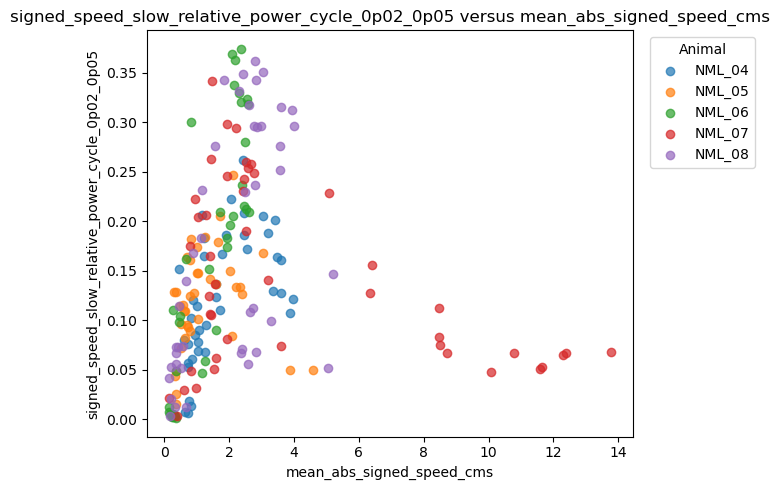

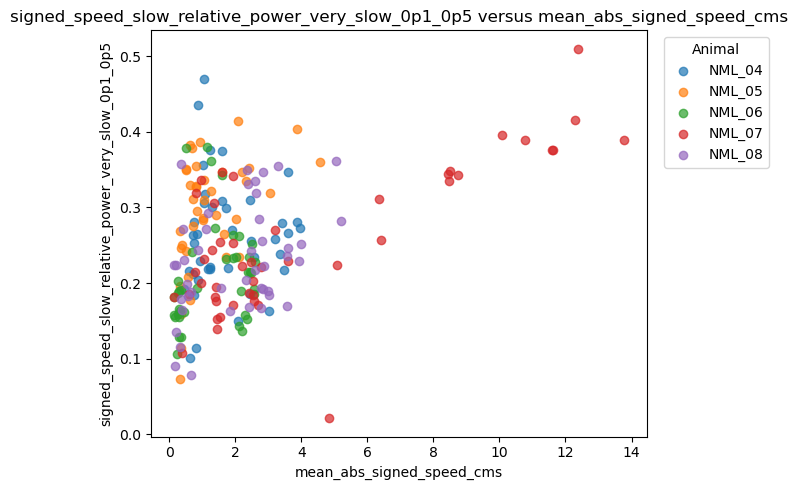

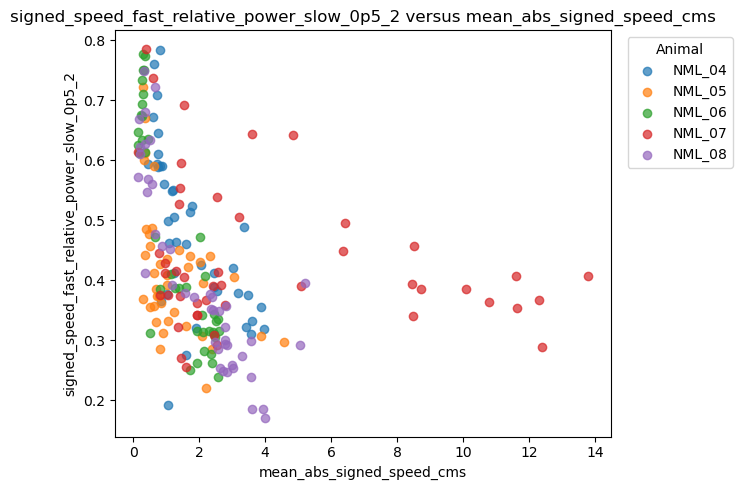

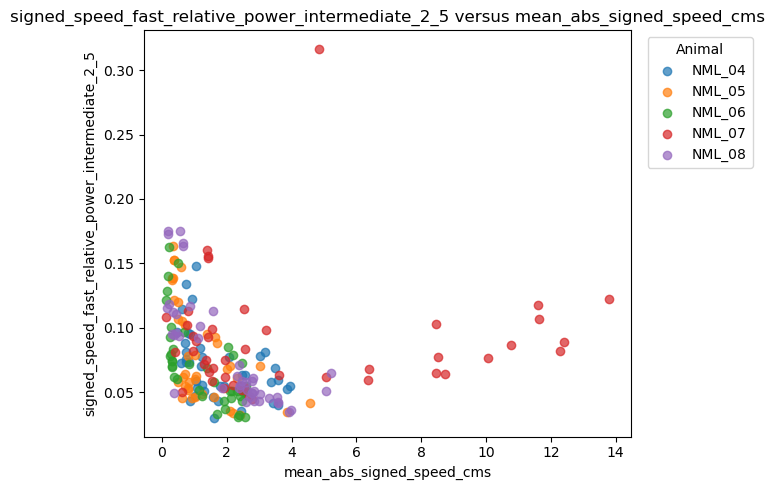

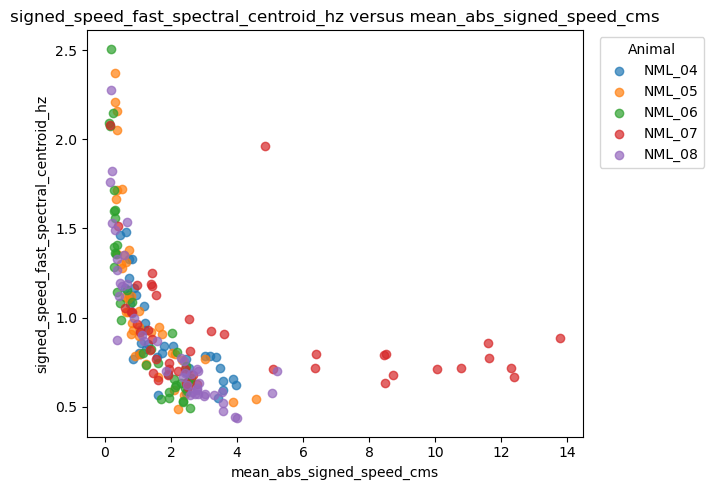

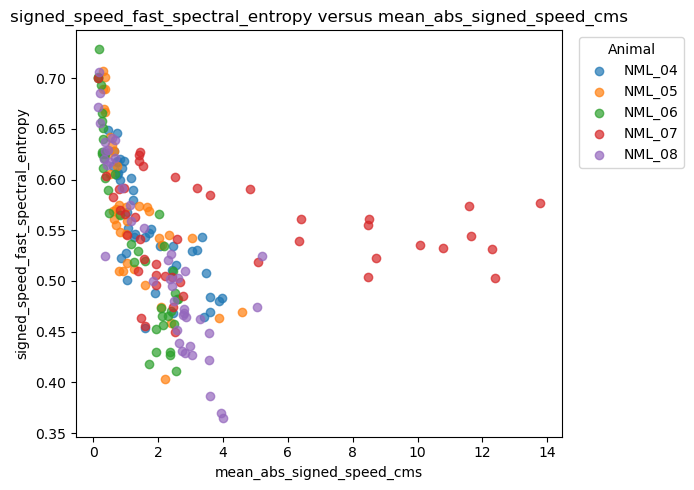

In [27]:
def plot_feature_against_speed(
    session_df,
    feature,
    speed_feature="mean_abs_signed_speed_cms",
):
    fig, ax = plt.subplots(figsize=(7, 5))

    for animal, animal_df in session_df.groupby("animal"):
        ax.scatter(
            animal_df[speed_feature],
            animal_df[feature],
            label=animal,
            alpha=0.70,
        )

    ax.set_xlabel(speed_feature)
    ax.set_ylabel(feature)
    ax.set_title(f"{feature} versus {speed_feature}")
    ax.legend(title="Animal", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()

    path = figure_dir / f"{feature}_versus_{speed_feature}.png"
    fig.savefig(path, dpi=200)
    plt.show()
    plt.close(fig)
    return path


for feature in [
    "signed_speed_slow_relative_power_cycle_0p02_0p05",
    "signed_speed_slow_relative_power_very_slow_0p1_0p5",
    "signed_speed_fast_relative_power_slow_0p5_2",
    "signed_speed_fast_relative_power_intermediate_2_5",
    "signed_speed_fast_spectral_centroid_hz",
    "signed_speed_fast_spectral_entropy",
]:
    plot_feature_against_speed(analysis_df, feature)

## 18. Files produced

Primary outputs:

```text
whole_session_spectral_features_corrected.csv
whole_session_psd_long_corrected.csv
whole_session_spectral_errors_corrected.csv
whole_session_qc_failed_sessions.csv
```

Animal-level summaries:

```text
animal_phase_median_features.csv
animal_phase_psd_median.csv
animal_phase_feature_slopes.csv
animal_phase_slope_consistency.csv
leave_one_animal_out_slope_sensitivity.csv
```

Figures:

```text
<PROC_BASE>/spectral_analysis/whole_session_corrected/figures/
```

## 19. Reload saved tables without rerunning native-rate processing

In [28]:
# whole_session_df = pd.read_csv(
#     whole_session_output_dir
#     / "whole_session_spectral_features_corrected.csv"
# )
#
# whole_session_psd_df = pd.read_csv(
#     whole_session_output_dir
#     / "whole_session_psd_long_corrected.csv"
# )
#
# whole_session_errors_df = pd.read_csv(
#     whole_session_output_dir
#     / "whole_session_spectral_errors_corrected.csv"
# )
#
# analysis_df = whole_session_df.loc[whole_session_df["qc_pass"]].copy()
# analysis_psd_df = whole_session_psd_df.loc[
#     whole_session_psd_df["qc_pass"]
# ].copy()